In [3]:
import os
import vr2p
import zarr
import math
import pickle
import warnings
import vr2p.signal
import numpy as np
import pandas as pd
import colorcet as cc
import seaborn as sns
from tqdm import tqdm
from vr2p import styles
from scipy import stats
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt 
from scipy.stats import rankdata
from matplotlib import cm, colors
mpl.rcParams['pdf.fonttype'] = 42
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from ipyfilechooser import FileChooser
from skimage.measure import regionprops
from sklearn.impute import SimpleImputer
from linear2ac.io import get_main_data_folder
from matplotlib.colors import ListedColormap
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from sklearn.decomposition import NMF
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.manifold import MDS
from scipy.stats import linregress
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
from scipy.stats import wilcoxon
from scipy.stats import sem, kruskal
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode
from sklearn.naive_bayes import GaussianNB
from scipy.ndimage import zoom
from scipy.ndimage import generic_filter
from sklearn.manifold import MDS
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
def load_animal_spatial_data_trial_by_trial(animal_name, base_path="/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Set A", bin_size=5, min_speed=5, track_size=230):

    data = vr2p.ExperimentData(f"{base_path}/{animal_name}-SetA.zarr/")
    edges = np.arange(0, track_size + bin_size, bin_size)
    n_bins = len(edges) - 1

    results = {"fields": [], "speed": [], "trial_types": [], "trial_numbers": [], "day_ind": []}

    for s, vr in enumerate(data.vr):
        print(f"On Session {s}")

        trial = vr.trial.copy()
        pos = vr.path.frame.copy().reset_index().merge(trial[["trial_number", "reward_id"]], on="trial_number")
        pos["speed"] = pos.vr2p.rolling_speed(window_size=100, ignore_threshold=7.5)

        F = data.signals.multi_session.Fdemix[int(s)][:]
        F = F - F.min(axis=1, keepdims=True)
        dff, _ = vr2p.signal.df_over_f0(F, "maximin", subtract_min=True, sigma_baseline=20, window_size=200)

        p = pos.loc[pos.speed >= min_speed, ["frame", "position", "trial_number", "reward_id", "speed"]].copy()

        valid = [t for t in trial.trial_number.values if len(p[p.trial_number == t]) and np.nanmax(p[p.trial_number == t].position) >= 226]

        if not valid:
            continue

        p = p[p.trial_number.isin(valid)].copy()
        p["trial_idx"] = p.trial_number.map({t: i for i, t in enumerate(valid)})
        p["bin"] = pd.cut(p.position, edges, include_lowest=True, labels=False)
        p = p.dropna(subset=["bin"]).copy()
        p["bin"] = p["bin"].astype(int)
        p = p[p.bin >= 0]

        mat = np.full((len(valid), F.shape[0], n_bins), np.nan)
        speed = np.full((len(valid), n_bins), np.nan)

        for (ti, bi), g in p.groupby(["trial_idx", "bin"]):
            frames = g.frame.to_numpy()
            mat[ti, :, bi] = dff[:, frames].mean(axis=1)
            speed[ti, bi] = g.speed.mean()

        results["fields"].append(mat)  # n_trials x n_cells x n_bins
        results["speed"].append(speed) # n_trials x n_bins
        results["trial_types"].append(trial.set_index("trial_number").loc[valid, "reward_id"].to_numpy())
        results["trial_numbers"].append(np.asarray(valid))
        results["day_ind"].append(s)

    return results

def load_animal_continuous_data(
        animal_name, 
        session, 
        base_path="/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Set A", 
        min_speed=0, 
        track_size=230):
    data = vr2p.ExperimentData(f"{base_path}/{animal_name}-SetA.zarr/")

    vr = data.vr[session]
    print(f"On Session {session}")

    # behavior
    trial = vr.trial.copy()

    pos = (vr.path.frame.copy().reset_index().merge(trial[["trial_number", "reward_id"]], on="trial_number"))
    pos["speed"] = pos.vr2p.rolling_speed(window_size=100, ignore_threshold=7.5)

    # neural data
    #F = data.signals.multi_session.Fdemix[int(session)][:]
    #F = F - F.min(axis=1, keepdims=True)

    #dff, _ = vr2p.signal.df_over_f0(F, "maximin", subtract_min=True, sigma_baseline=20, window_size=200)

    # deconvolved traces
    F_dcs = data.signals.multi_session.spks[int(session)][:]

    n_neurons, T = F_dcs.shape

    # valid frames
    p = pos.loc[pos.speed >= min_speed, ["frame", "position", "trial_number", "reward_id", "speed"]].copy()

    valid_trials = [t for t in trial.trial_number.values if len(p[p.trial_number == t]) and np.nanmax(p[p.trial_number == t].position) >= track_size - 4]

    if not valid_trials:
        return None

    p = p[p.trial_number.isin(valid_trials)].copy()
    p = p[(p.frame >= 0) & (p.frame < T)].copy()

    if len(p) == 0:
        return None

    # time from trial onset
    p["time_from_trial_onset"] = (p.groupby("trial_number")["frame"].transform(lambda x: x - x.min()))

    frames = p["frame"].to_numpy().astype(int)

    # lick data
    lick = vr.lick.copy()
    lick = lick[(lick.frame >= 0) & (lick.frame < T) & (lick.period == "TASK")]

    lick_frames = lick["frame"].to_numpy().astype(int)

    lick_binary_full = np.zeros(T)
    lick_binary_full[lick_frames] = 1

    lick_count_full = np.zeros(T)
    np.add.at(lick_count_full, lick_frames, 1)

    # -------- final output (no lists) --------
    results = {
        #"F": F[:, frames],
        #"dff": dff[:, frames],
        "F_dcs": F_dcs[:, frames],
        "position": p["position"].to_numpy(),
        "speed": p["speed"].to_numpy(),
        "time_from_trial_onset": p["time_from_trial_onset"].to_numpy(),
        "trial_type": p["reward_id"].to_numpy(),
        "trial_number": p["trial_number"].to_numpy(),
        "frame": frames,
        "day_ind": np.full(len(frames), session),
        "lick_binary": lick_binary_full[frames],
        "lick_count": lick_count_full[frames]}

    return results

def fill_nan_local_mean(mat, size=3):

    def nanmean_filter(x):
        x = x[np.isfinite(x)]
        return np.mean(x) if len(x) else np.nan

    mask = np.isnan(mat)
    filled = generic_filter(mat, nanmean_filter, size=size, mode="nearest")

    out = mat.copy()
    out[mask] = filled[mask]

    return out

def load_animal_spatial_data_session_by_session(animal, criteria="putative",
    base_setA="/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Set A",
    base_pf="/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/placeFields"):
    
    # --- load experiment data ---
    path = f"{base_setA}/{animal}-SetA.zarr/"
    data = vr2p.ExperimentData(path)

    # --- find consecutive days with Cue Set A only ---
    day_count = []
    for i in range(len(data.signals.multi_session.F)):
        sets = data.vr[i].trial.set.unique()
        if ("Cue Set A" in sets) and (len(sets) == 1):
            day_count.append(i)
        else:
            break

    max_day = int(max(day_count))  # last valid day index
    range_A = range(max_day + 1)

    # --- open PF zarr ---
    zarr_path = f"{base_pf}/{animal}-SetA.zarr-PF.zarr"
    zf = zarr.open(zarr_path, mode="r")

    # --- load PF analysis per day ---
    pf_all_T1 = [zf[f"Cue Set A/1/excl_no_response/{i}/{criteria}"][()] for i in range_A]
    pf_all_T2 = [zf[f"Cue Set A/2/excl_no_response/{i}/{criteria}"][()] for i in range_A]

    # --- load binned tuning curves per day ---
    binF_T1 = [pf_all_T1[i]["binF"] for i in range(len(pf_all_T1))]
    binF_T2 = [pf_all_T2[i]["binF"] for i in range(len(pf_all_T2))]

    binF_T1_all = np.array(binF_T1).T  # (N_cells, N_bins, N_sessions) depending on binF shape
    binF_T2_all = np.array(binF_T2).T

    return {
        "animal": animal,
        "path": path,
        "max_day": max_day,
        "range_A": range_A,
        "pf_all_T1": pf_all_T1,
        "pf_all_T2": pf_all_T2,
        "binF_T1_all": binF_T1_all,
        "binF_T2_all": binF_T2_all,
    }

def safe_nanmean(a, axis):
    count = np.sum(~np.isnan(a), axis=axis)
    total = np.nansum(a, axis=axis)

    out = np.full(total.shape, np.nan)
    mask = count > 0
    out[mask] = total[mask] / count[mask]

    return out

def build_trial_bin_population_matrix(
        PF,
        trial_types,
        trial_numbers,
        input_bin_size=5,
        output_bin_size=10,
        trial_block_size=3):
    """
    PF: n_trials x n_cells x n_bins

    trial_block_size:
        number of trials to average together.
        Trials are blocked separately within each trial type.

    returns:
        X:    (n_trial_blocks * n_output_bins) x n_cells
        meta: dataframe
    """

    n_trials, n_cells, n_bins_in = PF.shape

    trial_types = np.asarray(trial_types)
    trial_numbers = np.asarray(trial_numbers)

    if output_bin_size % input_bin_size != 0:
        raise ValueError("output_bin_size must be multiple of input_bin_size")

    combine = int(output_bin_size / input_bin_size)

    if n_bins_in % combine != 0:
        raise ValueError("n_bins not divisible by combine factor")

    if trial_block_size < 1:
        raise ValueError("trial_block_size must be >= 1")

    n_bins_out = n_bins_in // combine

    # spatial binning: trials x cells x output_bins
    PF_out = PF.reshape(n_trials, n_cells, n_bins_out, combine)
    PF_out = safe_nanmean(PF_out, axis=3)

    X_list = []
    meta = []

    block_counter = 0

    # block trials separately for each trial type
    for tt in np.unique(trial_types):

        trial_idx = np.where(trial_types == tt)[0]

        # keep original trial order
        trial_idx = trial_idx[np.argsort(trial_numbers[trial_idx])]

        for start in range(0, len(trial_idx), trial_block_size):

            block_trial_idx = trial_idx[start:start + trial_block_size]

            # average PF across trials within this block
            # shape: cells x bins
            PF_block = safe_nanmean(PF_out[block_trial_idx], axis=0)

            for b in range(n_bins_out):

                pop_vec = PF_block[:, b]

                X_list.append(pop_vec)

                meta.append({
                    "block_index": block_counter,
                    "trial_type": tt,
                    "trial_indices": block_trial_idx.tolist(),
                    "trial_numbers": trial_numbers[block_trial_idx].tolist(),
                    "block_start_trial": trial_numbers[block_trial_idx[0]],
                    "block_end_trial": trial_numbers[block_trial_idx[-1]],
                    "n_trials_in_block": len(block_trial_idx),
                    "bin": b,
                    "bin_start_cm": b * output_bin_size,
                    "bin_end_cm": (b + 1) * output_bin_size})

            block_counter += 1

    X = np.asarray(X_list)
    meta = pd.DataFrame(meta)

    return X, meta

def plot_embedding_3d_grid(
    embedding,
    Y,
    title="Embedding",
    n_plot=50000,
    position_range=None,
    normalize_embedding=True,
    marker_size=2.8,
    opacity=0.75,
):
    """
    2 x 3 interactive 3D grid.

    Row 1: trial type 1
        colored by scaled trial number, session, position

    Row 2: trial type 2
        colored by scaled trial number, session, position

    Y columns:
        0 = trial_type
        1 = trial_number
        2 = day_ind/session
        3 = position
        4 = spatial_bin
    """

    Z = np.asarray(embedding)
    Y = np.asarray(Y)

    # -------------------------------
    # base mask
    # -------------------------------

    mask = np.ones(len(Y), dtype=bool)

    sessions = np.sort(np.unique(Y[:, 2]))
    keep_sessions = sessions[:]
    mask &= np.isin(Y[:, 2], keep_sessions)

    # keep position range
    if position_range is not None:
        pmin, pmax = position_range
        mask &= (Y[:, 3] > pmin) & (Y[:, 3] < pmax)

    Z = Z[mask]
    Y = Y[mask]

    # -------------------------------
    # subsample
    # -------------------------------

    if len(Z) > n_plot:
        idx = np.random.choice(len(Z), size=n_plot, replace=False)
        Z = Z[idx]
        Y = Y[idx]

    # -------------------------------
    # normalize embedding
    # -------------------------------

    if normalize_embedding:
        Z = (Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-8)

    # -------------------------------
    # scaled trial number
    # within session x trial type
    # -------------------------------

    trial_scaled = np.full(len(Y), np.nan)

    for sess in np.unique(Y[:, 2]):
        for tt in np.unique(Y[:, 0]):

            m = (Y[:, 2] == sess) & (Y[:, 0] == tt)

            if np.sum(m) == 0:
                continue

            vals = Y[m, 1]

            trial_scaled[m] = (
                vals - vals.min()
            ) / (
                vals.max() - vals.min() + 1e-8
            )

    # -------------------------------
    # masks for trial types
    # -------------------------------

    mask_t1 = Y[:, 0] == 1
    mask_t2 = Y[:, 0] == 2

    # -------------------------------
    # figure
    # -------------------------------

    titles = [
        "T1: scaled trial number",
        "T1: session",
        "T1: position",
        "T2: scaled trial number",
        "T2: session",
        "T2: position",
    ]

    fig = make_subplots(
        rows=2,
        cols=3,
        specs=[
            [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
            [{"type": "scene"}, {"type": "scene"}, {"type": "scene"}],
        ],
        subplot_titles=titles,
        horizontal_spacing=0.02,
        vertical_spacing=0.05,
    )

    def add_panel(mask_panel, color_values, row, col, colorscale, color_title):

        fig.add_trace(
            go.Scatter3d(
                x=Z[mask_panel, 0],
                y=Z[mask_panel, 1],
                z=Z[mask_panel, 2],
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_values[mask_panel],
                    colorscale=colorscale,
                    opacity=opacity,
                    colorbar=dict(
                        title=color_title,
                        len=0.32,
                    ),
                ),
                customdata=np.column_stack([
                    Y[mask_panel, 0],
                    Y[mask_panel, 1],
                    Y[mask_panel, 2],
                    Y[mask_panel, 3],
                    Y[mask_panel, 4],
                ]),
                hovertemplate=(
                    "trial type=%{customdata[0]}<br>"
                    "trial=%{customdata[1]}<br>"
                    "session=%{customdata[2]}<br>"
                    "position=%{customdata[3]:.1f} cm<br>"
                    "bin=%{customdata[4]}<br>"
                    "<extra></extra>"
                ),
                showlegend=False,
            ),
            row=row,
            col=col,
        )

    # -------------------------------
    # row 1: trial type 1
    # -------------------------------

    add_panel(mask_t1, trial_scaled, 1, 1, "Jet", "trial")
    add_panel(mask_t1, Y[:, 2],       1, 2, "Viridis", "session")
    add_panel(mask_t1, Y[:, 3],       1, 3, "HSV", "position")

    # -------------------------------
    # row 2: trial type 2
    # -------------------------------

    add_panel(mask_t2, trial_scaled, 2, 1, "Jet", "trial")
    add_panel(mask_t2, Y[:, 2],       2, 2, "Viridis", "session")
    add_panel(mask_t2, Y[:, 3],       2, 3, "HSV", "position")

    # -------------------------------
    # layout
    # -------------------------------

    fig.update_layout(
        width=1600,
        height=900,
        title=title,
        margin=dict(l=0, r=0, b=0, t=50))

    fig.show()
    
def build_trial_bin_PV_single_trials(
    PF,
    trial_types,
    trial_numbers,
    session,
    bin_size=5):
    """
    PF: trials x cells x bins

    Returns:
        X:    (trials * bins) x cells
        meta: dataframe with trial/bin/session info
    """

    PF = np.asarray(PF, float)
    trial_types = np.asarray(trial_types)
    trial_numbers = np.asarray(trial_numbers)

    n_trials, n_cells, n_bins = PF.shape

    X_list = []
    meta = []

    for tr in range(n_trials):
        for b in range(n_bins):

            X_list.append(PF[tr, :, b])

            meta.append({
                "session": session,
                "trial_index": tr,
                "trial_number": trial_numbers[tr],
                "trial_type": trial_types[tr],
                "bin": b,
                "bin_1based": b + 1,
                "bin_start_cm": b * bin_size,
                "bin_end_cm": (b + 1) * bin_size})

    return np.asarray(X_list), pd.DataFrame(meta)

def get_engaged_trials(PF, z_threshold=-2):
    """Return engaged-trial mask based on trial-by-trial population similarity."""
    n_trials = PF.shape[0]

    X = np.nan_to_num(PF.reshape(n_trials, -1))
    R = np.corrcoef(X)
    np.fill_diagonal(R, np.nan)

    trial_score = np.nanmean(R, axis=1)
    med = np.nanmedian(trial_score)
    mad = np.nanmedian(np.abs(trial_score - med))

    if mad == 0 or not np.isfinite(mad):
        return np.ones(n_trials, dtype=bool)

    robust_z = 0.6745 * (trial_score - med) / mad
    return robust_z > z_threshold

In [5]:
# This part takes about 105 mins
animals = ['Tyche-A4', 'Tyche-A5', 'Tyche-A7', 'Tyche-B2', 'Tyche-B3', 'Tyche-B4', 'Tyche-B5']

Data_trial = {}
for animal in animals:
    print(f'Loading data for animal {animal}')
    Data_trial[animal] = load_animal_spatial_data_trial_by_trial(animal)

Loading data for animal Tyche-A4
On Session 0
On Session 1
On Session 2
On Session 3
On Session 4
On Session 5
On Session 6
On Session 7
On Session 8
On Session 9
Loading data for animal Tyche-A5
On Session 0
On Session 1
On Session 2
On Session 3
On Session 4
On Session 5
Loading data for animal Tyche-A7
On Session 0
On Session 1
On Session 2
On Session 3
On Session 4
On Session 5
On Session 6
On Session 7
On Session 8
Loading data for animal Tyche-B2
On Session 0
On Session 1
On Session 2
On Session 3
On Session 4
On Session 5
On Session 6
Loading data for animal Tyche-B3
On Session 0
On Session 1
On Session 2
On Session 3
On Session 4
On Session 5
On Session 6
On Session 7
On Session 8
On Session 9
On Session 10
On Session 11
On Session 12
On Session 13
On Session 14
Loading data for animal Tyche-B4
On Session 0
On Session 1
On Session 2
On Session 3
On Session 4
Loading data for animal Tyche-B5
On Session 0
On Session 1
On Session 2
On Session 3
On Session 4
On Session 5
On Session

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

pdf_path = os.path.join(save_dir, "session_by_session_RSM_all_animals_TT1.pdf")

trial_type = 1
exclude = {0: [6, 7, 8], 3: [6]}

with PdfPages(pdf_path) as pdf:

    for ai, animal in enumerate(animals):

        data = Data_trial[animal]
        n_sessions = len(data["fields"])

        session_vectors = []
        valid_sessions = []

        for sess in range(n_sessions):

            if ai in exclude and sess in exclude[ai]:
                continue

            PF = np.asarray(data["fields"][sess], float)
            tt = np.asarray(data["trial_types"][sess])

            idx = np.where(tt == trial_type)[0]
            PF = PF[idx]

            n_trials = PF.shape[0]
            if n_trials < 5:
                continue

            X = PF.reshape(n_trials, -1)
            X = np.nan_to_num(X)

            session_vec = np.nanmean(X, axis=0)

            session_vectors.append(session_vec)
            valid_sessions.append(sess)

        if len(session_vectors) < 2:
            print(f"{animal}: skipped, fewer than 2 valid sessions")
            continue

        session_vectors = np.asarray(session_vectors)
        session_RSM = np.corrcoef(session_vectors)

        fig, ax = plt.subplots(figsize=(5, 5))

        im = ax.imshow(
            session_RSM,
            cmap="coolwarm",
            vmin=-0.8,
            vmax=0.8,
            origin="upper"
        )

        ax.set_title(f"{animal} | session-by-session similarity | TT={trial_type}")

        ax.set_xticks(np.arange(len(valid_sessions)))
        ax.set_yticks(np.arange(len(valid_sessions)))

        ax.set_xticklabels(valid_sessions, fontsize=8)
        ax.set_yticklabels(valid_sessions, fontsize=8)

        ax.set_xlabel("Session")
        ax.set_ylabel("Session")

        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label("Correlation")

        plt.tight_layout()

        pdf.savefig(fig, dpi=300)
        plt.close(fig)

print(f"Saved PDF to:\n{pdf_path}")

Saved PDF to:
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/session_by_session_RSM_all_animals_TT1.pdf


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

pdf_path = os.path.join(
    save_dir,
    "block_by_block_RSM_across_sessions_TT1_block3.pdf"
)

trial_type = 1
block_size = 3

exclude = {
    0: [6, 7, 8],
    3: [6]
    }

with PdfPages(pdf_path) as pdf:

    for ai, animal in enumerate(animals):

        data = Data_trial[animal]
        n_sessions = len(data["fields"])

        X_blocks_all = []
        block_session_ids = []
        session_boundaries = []
        block_counter = 0

        for sess in range(n_sessions):

            # exclusions
            if ai in exclude and sess in exclude[ai]:
                continue

            PF = np.asarray(data["fields"][sess], float)
            tt = np.asarray(data["trial_types"][sess])

            idx = np.where(tt == trial_type)[0]
            PF = PF[idx]

            n_trials = PF.shape[0]

            if n_trials < block_size:
                continue

            n_blocks = n_trials // block_size

            # keep only complete blocks
            PF = PF[:n_blocks * block_size]

            # blocks x block_size x cells x bins
            PF_blocks = PF.reshape(
                n_blocks,
                block_size,
                PF.shape[1],
                PF.shape[2]
            )

            # average within block
            PF_blocks_mean = np.nanmean(PF_blocks, axis=1)

            # flatten block vectors
            X_blocks = PF_blocks_mean.reshape(n_blocks, -1)
            X_blocks = np.nan_to_num(X_blocks)

            X_blocks_all.append(X_blocks)
            block_session_ids.extend([sess] * n_blocks)

            block_counter += n_blocks
            session_boundaries.append(block_counter)

        if len(X_blocks_all) == 0:
            print(f"{animal}: no valid sessions")
            continue

        X_blocks_all = np.vstack(X_blocks_all)
        block_session_ids = np.asarray(block_session_ids)

        # block-by-block similarity matrix
        RSM_blocks = np.corrcoef(X_blocks_all)

        # -------------------------------------------------
        # plot
        # -------------------------------------------------

        fig, ax = plt.subplots(figsize=(8, 8))

        im = ax.imshow(
            RSM_blocks,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            origin="upper",
            aspect="equal"
        )

        # session boundaries
        for b in session_boundaries[:-1]:
            ax.axhline(
                b - 0.5,
                color="white",
                linestyle="--",
                linewidth=1
            )

            ax.axvline(
                b - 0.5,
                color="white",
                linestyle="--",
                linewidth=1
            )

        # session labels
        centers = []
        labels = []

        start = 0

        for b in session_boundaries:

            end = b

            sess = block_session_ids[start]
            center = (start + end - 1) / 2

            centers.append(center)
            labels.append(sess)

            start = end

        ax.set_xticks(centers)
        ax.set_yticks(centers)

        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)

        ax.set_xlabel("Session")
        ax.set_ylabel("Session")

        ax.set_title(
            f"{animal} | block-by-block RSM across sessions | "
            f"TT={trial_type}, block={block_size} trials"
        )

        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label("Block-block correlation")

        plt.tight_layout()

        # save to pdf
        pdf.savefig(fig, dpi=300)
        plt.close(fig)

print(f"Saved PDF to:\n{pdf_path}")

/tmp/ipykernel_13163/1846942087.py:65: RuntimeWarning: Mean of empty slice
  PF_blocks_mean = np.nanmean(PF_blocks, axis=1)


Saved PDF to:
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/block_by_block_RSM_across_sessions_TT1_block3.pdf


In [9]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

pdf_path = os.path.join(
    save_dir,
    "block_by_block_RSM_per_session_TT1_block3.pdf"
)

trial_type = 1
block_size = 3
n_cols = 8

with PdfPages(pdf_path) as pdf:

    for animal in animals:

        data = Data_trial[animal]
        n_sessions = len(data["fields"])

        rsms = []
        sess_ids = []

        for sess in range(n_sessions):

            PF = np.asarray(data["fields"][sess], float)
            tt = np.asarray(data["trial_types"][sess])

            idx = np.where(tt == trial_type)[0]
            PF = PF[idx]

            engaged_trials = get_engaged_trials(PF, z_threshold=-2)
            PF = PF[engaged_trials]

            n_trials = PF.shape[0]

            if n_trials < block_size * 2:
                continue

            # keep only complete blocks
            n_blocks = n_trials // block_size
            PF = PF[:n_blocks * block_size]

            # trials -> blocks
            PF_blocks = PF.reshape(
                n_blocks,
                block_size,
                PF.shape[1],
                PF.shape[2]
            )

            # average trials within each block
            PF_blocks = np.nanmean(PF_blocks, axis=1)

            if PF_blocks.shape[0] < 2:
                continue

            X = PF_blocks.reshape(PF_blocks.shape[0], -1)
            X = np.nan_to_num(X)

            RSM = np.corrcoef(X)

            rsms.append(RSM)
            sess_ids.append(sess)

        if len(rsms) == 0:
            print(f"{animal}: no valid sessions")
            continue

        n_panels = len(rsms)
        n_rows = math.ceil(n_panels / n_cols)

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(2.0 * n_cols, 2.0 * n_rows),
            constrained_layout=True
        )

        axes = np.asarray(axes).reshape(-1)

        for ax, RSM, sess in zip(axes, rsms, sess_ids):

            im = ax.imshow(
                RSM,
                cmap="coolwarm",
                vmin=-1,
                vmax=1,
                origin="upper",
                aspect="auto"
            )

            ax.set_title(
                f"S{sess} | blocks={RSM.shape[0]}",
                fontsize=8
            )

            ax.set_xticks([])
            ax.set_yticks([])

        # hide unused panels
        for ax in axes[n_panels:]:
            ax.axis("off")

        fig.suptitle(
            f"{animal} | block-by-block RSM | "
            f"TT={trial_type} | block={block_size} trials",
            fontsize=14
        )

        cbar = fig.colorbar(im, ax=axes[:n_panels], shrink=0.6)
        cbar.set_label("Block-block correlation")

        pdf.savefig(fig, dpi=300)
        plt.close(fig)

print(f"Saved PDF to:\n{pdf_path}")

/tmp/ipykernel_13163/4026607612.py:58: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)


Saved PDF to:
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/block_by_block_RSM_per_session_TT1_block3.pdf


/tmp/ipykernel_13163/3741704620.py:48: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)


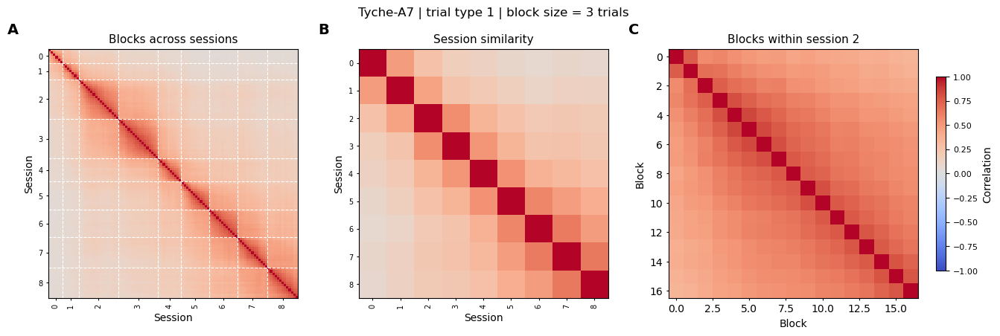

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/Tyche-A7_example_RSM_summary_TT1_block3.pdf
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/Tyche-A7_example_RSM_summary_TT1_block3.png


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# parameters
# -----------------------------

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

animal = animals[2]
ai = 2

trial_type = 1
block_size = 3
example_session = 2

exclude = {
    0: [6, 7, 8],
    3: [6]
}

vmin, vmax = -1, 1
cmap = "coolwarm"

# -----------------------------
# helper functions
# -----------------------------

def get_block_vectors(PF, block_size=3):
    """
    PF: trials x cells x bins
    returns: blocks x features
    """
    n_trials = PF.shape[0]
    n_blocks = n_trials // block_size

    PF = PF[:n_blocks * block_size]

    PF_blocks = PF.reshape(
        n_blocks,
        block_size,
        PF.shape[1],
        PF.shape[2]
    )

    PF_blocks = np.nanmean(PF_blocks, axis=1)

    X = PF_blocks.reshape(n_blocks, -1)
    X = np.nan_to_num(X)

    return X


def clean_trial_type_PF(data, sess, trial_type=1, use_engaged=False):
    PF = np.asarray(data["fields"][sess], float)
    tt = np.asarray(data["trial_types"][sess])

    idx = np.where(tt == trial_type)[0]
    PF = PF[idx]

    if use_engaged:
        engaged_trials = get_engaged_trials(PF, z_threshold=-2)
        PF = PF[engaged_trials]

    return PF


# -----------------------------
# load animal
# -----------------------------

data = Data_trial[animal]
n_sessions = len(data["fields"])

# =========================================================
# 1) block-by-block RSM across all sessions
# =========================================================

X_blocks_all = []
block_session_ids = []
session_boundaries = []
block_counter = 0

for sess in range(n_sessions):

    if ai in exclude and sess in exclude[ai]:
        continue

    PF = clean_trial_type_PF(
        data,
        sess,
        trial_type=trial_type,
        use_engaged=True
    )

    if PF.shape[0] < block_size:
        continue

    X_blocks = get_block_vectors(PF, block_size=block_size)

    if X_blocks.shape[0] < 2:
        continue

    X_blocks_all.append(X_blocks)
    block_session_ids.extend([sess] * X_blocks.shape[0])

    block_counter += X_blocks.shape[0]
    session_boundaries.append(block_counter)

X_blocks_all = np.vstack(X_blocks_all)
block_session_ids = np.asarray(block_session_ids)

RSM_blocks_all = np.corrcoef(X_blocks_all)

# session centers for panel 1
block_centers = []
block_labels = []

start = 0
for b in session_boundaries:
    end = b
    sess = block_session_ids[start]
    center = (start + end - 1) / 2

    block_centers.append(center)
    block_labels.append(sess)

    start = end


# =========================================================
# 2) session-by-session RSM
# =========================================================

session_vectors = []
valid_sessions = []

for sess in range(n_sessions):

    if ai in exclude and sess in exclude[ai]:
        continue

    PF = clean_trial_type_PF(
        data,
        sess,
        trial_type=trial_type,
        use_engaged=False
    )

    if PF.shape[0] < 5:
        continue

    X = PF.reshape(PF.shape[0], -1)
    X = np.nan_to_num(X)

    session_vec = np.nanmean(X, axis=0)

    session_vectors.append(session_vec)
    valid_sessions.append(sess)

session_vectors = np.asarray(session_vectors)
RSM_sessions = np.corrcoef(session_vectors)


# =========================================================
# 3) block-by-block RSM for one session
# =========================================================

PF_sess = clean_trial_type_PF(
    data,
    example_session,
    trial_type=trial_type,
    use_engaged=True
)

X_blocks_sess = get_block_vectors(PF_sess, block_size=block_size)
RSM_blocks_sess = np.corrcoef(X_blocks_sess)


# =========================================================
# plot 1 x 3 publication-quality figure
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.2),
    constrained_layout=True
)

panel_titles = [
    "Blocks across sessions",
    "Session similarity",
    f"Blocks within session {example_session}"
]

# -----------------------------
# panel 1
# -----------------------------

ax = axes[0]

im0 = ax.imshow(
    RSM_blocks_all,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    origin="upper",
    aspect="equal"
)

for b in session_boundaries[:-1]:
    ax.axhline(b - 0.5, color="white", linestyle="--", linewidth=0.8)
    ax.axvline(b - 0.5, color="white", linestyle="--", linewidth=0.8)

ax.set_xticks(block_centers)
ax.set_yticks(block_centers)

ax.set_xticklabels(block_labels, rotation=90, fontsize=7)
ax.set_yticklabels(block_labels, fontsize=7)

ax.set_xlabel("Session", fontsize=10)
ax.set_ylabel("Session", fontsize=10)
ax.set_title(panel_titles[0], fontsize=11)

# -----------------------------
# panel 2
# -----------------------------

ax = axes[1]

im1 = ax.imshow(
    RSM_sessions,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    origin="upper",
    aspect="equal"
)

ax.set_xticks(np.arange(len(valid_sessions)))
ax.set_yticks(np.arange(len(valid_sessions)))

ax.set_xticklabels(valid_sessions, rotation=90, fontsize=7)
ax.set_yticklabels(valid_sessions, fontsize=7)

ax.set_xlabel("Session", fontsize=10)
ax.set_ylabel("Session", fontsize=10)
ax.set_title(panel_titles[1], fontsize=11)

# -----------------------------
# panel 3
# -----------------------------

ax = axes[2]

im2 = ax.imshow(
    RSM_blocks_sess,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    origin="upper",
    aspect="equal"
)

ax.set_xlabel("Block", fontsize=10)
ax.set_ylabel("Block", fontsize=10)
ax.set_title(panel_titles[2], fontsize=11)

# -----------------------------
# shared styling
# -----------------------------

for i, ax in enumerate(axes):
    ax.tick_params(length=2, width=0.8)
    ax.text(
        -0.12,
        1.05,
        chr(ord("A") + i),
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="right"
    )

# shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes,
    shrink=0.78,
    pad=0.02
)
cbar.set_label("Correlation", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    f"{animal} | trial type {trial_type} | block size = {block_size} trials",
    fontsize=12,
    y=1.04
)

# -----------------------------
# save
# -----------------------------

pdf_path = os.path.join(
    save_dir,
    f"{animal}_example_RSM_summary_TT{trial_type}_block{block_size}.pdf"
)

png_path = os.path.join(
    save_dir,
    f"{animal}_example_RSM_summary_TT{trial_type}_block{block_size}.png"
)

fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")

In [11]:
import numpy as np
import pandas as pd

trial_type = 1
block_size = 3

exclude = {
    0: [6, 7, 8],
    3: [6]
}

def corr_vec(a, b):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()

    valid = np.isfinite(a) & np.isfinite(b)
    a = a[valid]
    b = b[valid]

    if len(a) < 2:
        return np.nan

    if np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return np.nan

    return np.corrcoef(a, b)[0, 1]


def get_session_blocks(data, sess, trial_type=1, block_size=3, use_engaged=True):

    PF = np.asarray(data["fields"][sess], float)
    tt = np.asarray(data["trial_types"][sess])

    idx = np.where(tt == trial_type)[0]
    PF = PF[idx]

    if use_engaged:
        engaged_trials = get_engaged_trials(PF, z_threshold=-2)
        PF = PF[engaged_trials]

    n_trials = PF.shape[0]

    if n_trials < block_size * 2:
        return None

    n_blocks = n_trials // block_size
    PF = PF[:n_blocks * block_size]

    PF_blocks = PF.reshape(
        n_blocks,
        block_size,
        PF.shape[1],
        PF.shape[2]
    )

    PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins

    X_blocks = PF_blocks.reshape(n_blocks, -1)
    X_blocks = np.nan_to_num(X_blocks)

    return X_blocks


rows = []

for ai, animal in enumerate(animals):

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    # first compute block vectors for every valid session
    session_blocks = {}

    for sess in range(n_sessions):

        if ai in exclude and sess in exclude[ai]:
            continue

        X_blocks = get_session_blocks(
            data,
            sess,
            trial_type=trial_type,
            block_size=block_size,
            use_engaged=True
        )

        if X_blocks is None:
            continue

        session_blocks[sess] = X_blocks

    valid_sessions = sorted(session_blocks.keys())

    for i, sess in enumerate(valid_sessions):

        X_blocks = session_blocks[sess]
        n_blocks = X_blocks.shape[0]

        # 1. average correlation of consecutive blocks
        consecutive_corrs = []

        for b in range(n_blocks - 1):
            r = corr_vec(X_blocks[b], X_blocks[b + 1])
            consecutive_corrs.append(r)

        mean_consecutive_block_corr = np.nanmean(consecutive_corrs)

        # 2. correlation of first and last block within session
        first_last_block_corr = corr_vec(X_blocks[0], X_blocks[-1])

        # 3. correlation of last block of current session
        #    with first block of next valid session
        if i < len(valid_sessions) - 1:
            next_sess = valid_sessions[i + 1]
            X_next = session_blocks[next_sess]
            last_current_first_next_corr = corr_vec(X_blocks[-1], X_next[0])
        else:
            next_sess = np.nan
            last_current_first_next_corr = np.nan

        rows.append({
            "animal": animal,
            "session": sess,
            "next_session": next_sess,
            "n_blocks": n_blocks,
            "mean_consecutive_block_corr": mean_consecutive_block_corr,
            "first_last_block_corr": first_last_block_corr,
            "last_current_first_next_corr": last_current_first_next_corr
        })

df_block_similarity = pd.DataFrame(rows)

df_block_similarity

/tmp/ipykernel_13163/829298127.py:56: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins


,animal,session,next_session,n_blocks,mean_consecutive_block_corr,first_last_block_corr,last_current_first_next_corr
0,Tyche-A4,0,1.0,10,0.616556,0.158669,0.396458
1,Tyche-A4,1,2.0,10,0.732036,0.272646,0.430492
2,Tyche-A4,2,3.0,6,0.721882,0.488426,0.449923
3,Tyche-A4,3,4.0,10,0.772012,0.390062,0.447767
4,Tyche-A4,4,5.0,14,0.845689,0.468627,0.434652
5,Tyche-A4,5,9.0,12,0.811103,0.508004,0.264583
6,Tyche-A4,9,NaN,15,0.778136,0.461536,NaN
7,Tyche-A5,0,1.0,12,0.383223,0.082653,0.295065
8,Tyche-A5,1,2.0,11,0.693970,0.346307,0.404368
9,Tyche-A5,2,3.0,13,0.769660,0.422762,0.485635


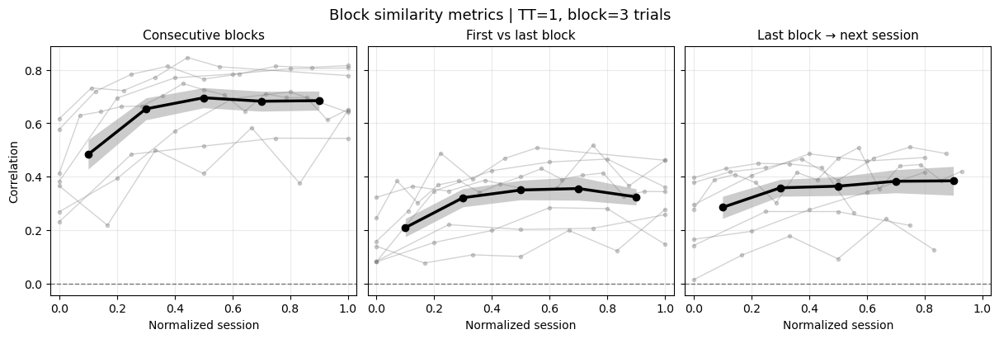

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/block_similarity_metrics_TT1_block3.pdf
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/block_similarity_metrics_TT1_block3.png


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

metric_cols = [
    "mean_consecutive_block_corr",
    "first_last_block_corr",
    "last_current_first_next_corr"
]

metric_labels = [
    "Consecutive blocks",
    "First vs last block",
    "Last block → next session"
]

# -------------------------------------------------------
# normalize session index within each animal
# -------------------------------------------------------

df_plot = df_block_similarity.copy()

df_plot["session_norm"] = np.nan

for animal in df_plot["animal"].unique():

    m = df_plot["animal"] == animal
    sess = df_plot.loc[m, "session"].values.astype(float)

    if len(sess) > 1:
        df_plot.loc[m, "session_norm"] = (
            (sess - np.nanmin(sess))
            / (np.nanmax(sess) - np.nanmin(sess))
        )
    else:
        df_plot.loc[m, "session_norm"] = 0

# -------------------------------------------------------
# figure
# -------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, metric, label in zip(axes, metric_cols, metric_labels):

    # individual animal trajectories
    for animal in df_plot["animal"].unique():

        d = (
            df_plot[df_plot["animal"] == animal]
            .sort_values("session_norm")
        )

        ax.plot(
            d["session_norm"],
            d[metric],
            "-o",
            lw=1,
            ms=3,
            alpha=0.35,
            color="gray"
        )

    # population mean ± SEM
    bins = np.linspace(0, 1, 6)
    centers = (bins[:-1] + bins[1:]) / 2

    mean_vals = []
    sem_vals = []

    for i in range(len(bins) - 1):

        if i == len(bins) - 2:
            dd = df_plot[
                (df_plot["session_norm"] >= bins[i]) &
                (df_plot["session_norm"] <= bins[i + 1])
            ]
        else:
            dd = df_plot[
                (df_plot["session_norm"] >= bins[i]) &
                (df_plot["session_norm"] < bins[i + 1])
            ]

        vals = dd[metric].values.astype(float)
        vals = vals[np.isfinite(vals)]

        mean_vals.append(np.nanmean(vals))
        sem_vals.append(
            np.nanstd(vals, ddof=1) / np.sqrt(len(vals))
        )

    mean_vals = np.asarray(mean_vals)
    sem_vals = np.asarray(sem_vals)

    ax.plot(
        centers,
        mean_vals,
        "-o",
        lw=2.5,
        ms=6,
        color="black"
    )

    ax.fill_between(
        centers,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color="black",
        alpha=0.2,
        linewidth=0
    )

    ax.axhline(
        0,
        color="k",
        ls="--",
        lw=1,
        alpha=0.5
    )

    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Normalized session")
    ax.set_xlim(-0.03, 1.03)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Correlation")

fig.suptitle(
    f"Block similarity metrics | TT={trial_type}, block={block_size} trials",
    fontsize=13
)

# -------------------------------------------------------
# save
# -------------------------------------------------------

pdf_path = os.path.join(
    save_dir,
    f"block_similarity_metrics_TT{trial_type}_block{block_size}.pdf"
)

png_path = os.path.join(
    save_dir,
    f"block_similarity_metrics_TT{trial_type}_block{block_size}.png"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")

/tmp/ipykernel_13163/3164143613.py:66: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)


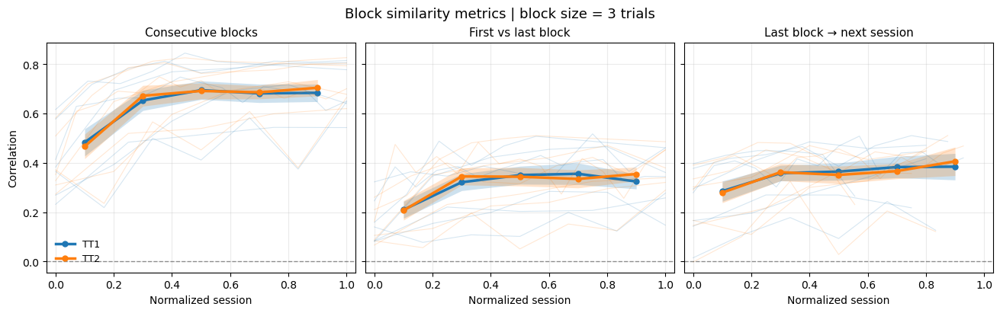

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/block_similarity_metrics_TT1_vs_TT2_block3.pdf
/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper/block_similarity_metrics_TT1_vs_TT2_block3.png


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

block_size = 3

exclude = {
    0: [6, 7, 8],
    3: [6]
}

# -------------------------------------------------------
# helper functions
# -------------------------------------------------------

def corr_vec(a, b):

    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()

    valid = np.isfinite(a) & np.isfinite(b)

    a = a[valid]
    b = b[valid]

    if len(a) < 2:
        return np.nan

    if np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return np.nan

    return np.corrcoef(a, b)[0, 1]


def get_session_blocks(data, sess, trial_type=1, block_size=3):

    PF = np.asarray(data["fields"][sess], float)
    tt = np.asarray(data["trial_types"][sess])

    idx = np.where(tt == trial_type)[0]
    PF = PF[idx]

    engaged_trials = get_engaged_trials(PF, z_threshold=-2)
    PF = PF[engaged_trials]

    n_trials = PF.shape[0]

    if n_trials < block_size * 2:
        return None

    n_blocks = n_trials // block_size

    PF = PF[:n_blocks * block_size]

    PF_blocks = PF.reshape(
        n_blocks,
        block_size,
        PF.shape[1],
        PF.shape[2]
    )

    PF_blocks = np.nanmean(PF_blocks, axis=1)

    X_blocks = PF_blocks.reshape(n_blocks, -1)
    X_blocks = np.nan_to_num(X_blocks)

    return X_blocks


# -------------------------------------------------------
# compute metrics for TT1 and TT2
# -------------------------------------------------------

all_rows = []

for trial_type in [1, 2]:

    for ai, animal in enumerate(animals):

        data = Data_trial[animal]
        n_sessions = len(data["fields"])

        session_blocks = {}

        for sess in range(n_sessions):

            if ai in exclude and sess in exclude[ai]:
                continue

            X_blocks = get_session_blocks(
                data,
                sess,
                trial_type=trial_type,
                block_size=block_size
            )

            if X_blocks is None:
                continue

            session_blocks[sess] = X_blocks

        valid_sessions = sorted(session_blocks.keys())

        for i, sess in enumerate(valid_sessions):

            X_blocks = session_blocks[sess]
            n_blocks = X_blocks.shape[0]

            # consecutive blocks
            consecutive_corrs = []

            for b in range(n_blocks - 1):

                r = corr_vec(
                    X_blocks[b],
                    X_blocks[b + 1]
                )

                consecutive_corrs.append(r)

            mean_consecutive_block_corr = np.nanmean(consecutive_corrs)

            # first vs last
            first_last_block_corr = corr_vec(
                X_blocks[0],
                X_blocks[-1]
            )

            # current last vs next first
            if i < len(valid_sessions) - 1:

                next_sess = valid_sessions[i + 1]
                X_next = session_blocks[next_sess]

                last_current_first_next_corr = corr_vec(
                    X_blocks[-1],
                    X_next[0]
                )

            else:

                last_current_first_next_corr = np.nan

            all_rows.append({
                "animal": animal,
                "trial_type": f"TT{trial_type}",
                "session": sess,
                "mean_consecutive_block_corr": mean_consecutive_block_corr,
                "first_last_block_corr": first_last_block_corr,
                "last_current_first_next_corr": last_current_first_next_corr
            })

df_plot = pd.DataFrame(all_rows)

# -------------------------------------------------------
# normalize session index within animal + TT
# -------------------------------------------------------

df_plot["session_norm"] = np.nan

for animal in df_plot["animal"].unique():

    for tt in ["TT1", "TT2"]:

        m = (
            (df_plot["animal"] == animal) &
            (df_plot["trial_type"] == tt)
        )

        sess = df_plot.loc[m, "session"].values.astype(float)

        if len(sess) > 1:

            df_plot.loc[m, "session_norm"] = (
                (sess - np.nanmin(sess))
                / (np.nanmax(sess) - np.nanmin(sess))
            )

        else:
            df_plot.loc[m, "session_norm"] = 0

# -------------------------------------------------------
# visualization
# -------------------------------------------------------

metric_cols = [
    "mean_consecutive_block_corr",
    "first_last_block_corr",
    "last_current_first_next_corr"
]

metric_labels = [
    "Consecutive blocks",
    "First vs last block",
    "Last block → next session"
]

colors = {
    "TT1": "tab:blue",
    "TT2": "tab:orange"
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, metric, label in zip(axes, metric_cols, metric_labels):

    for tt in ["TT1", "TT2"]:

        dtt = df_plot[df_plot["trial_type"] == tt]

        # individual animals
        for animal in dtt["animal"].unique():

            d = (
                dtt[dtt["animal"] == animal]
                .sort_values("session_norm")
            )

            ax.plot(
                d["session_norm"],
                d[metric],
                "-",
                lw=0.8,
                alpha=0.18,
                color=colors[tt]
            )

        # mean ± sem
        bins = np.linspace(0, 1, 6)
        centers = (bins[:-1] + bins[1:]) / 2

        mean_vals = []
        sem_vals = []

        for i in range(len(bins) - 1):

            if i == len(bins) - 2:
                dd = dtt[
                    (dtt["session_norm"] >= bins[i]) &
                    (dtt["session_norm"] <= bins[i + 1])
                ]
            else:
                dd = dtt[
                    (dtt["session_norm"] >= bins[i]) &
                    (dtt["session_norm"] < bins[i + 1])
                ]

            vals = dd[metric].values.astype(float)
            vals = vals[np.isfinite(vals)]

            mean_vals.append(np.nanmean(vals))

            sem_vals.append(
                np.nanstd(vals, ddof=1)
                / np.sqrt(len(vals))
            )

        mean_vals = np.asarray(mean_vals)
        sem_vals = np.asarray(sem_vals)

        ax.plot(
            centers,
            mean_vals,
            "-o",
            lw=2.5,
            ms=5,
            color=colors[tt],
            label=tt
        )

        ax.fill_between(
            centers,
            mean_vals - sem_vals,
            mean_vals + sem_vals,
            color=colors[tt],
            alpha=0.22,
            linewidth=0
        )

    ax.axhline(
        0,
        color="k",
        linestyle="--",
        linewidth=1,
        alpha=0.4
    )

    ax.set_title(label, fontsize=11)

    ax.set_xlabel("Normalized session")
    ax.set_xlim(-0.03, 1.03)

    ax.grid(alpha=0.25)

axes[0].set_ylabel("Correlation")

axes[0].legend(
    frameon=False,
    fontsize=9,
    loc="lower left"
)

fig.suptitle(
    f"Block similarity metrics | block size = {block_size} trials",
    fontsize=13
)

# -------------------------------------------------------
# save
# -------------------------------------------------------

pdf_path = os.path.join(
    save_dir,
    f"block_similarity_metrics_TT1_vs_TT2_block{block_size}.pdf"
)

png_path = os.path.join(
    save_dir,
    f"block_similarity_metrics_TT1_vs_TT2_block{block_size}.png"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")

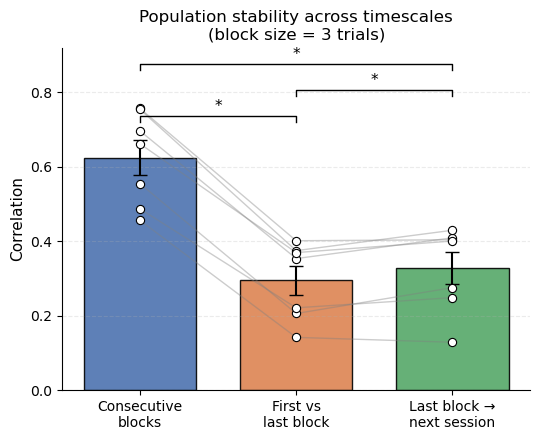

                                          comparison         p
0  mean_consecutive_block_corr vs first_last_bloc...  0.015625
1  mean_consecutive_block_corr vs last_current_fi...  0.015625
2  first_last_block_corr vs last_current_first_ne...  0.046875
Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/summary_three_similarity_metrics_block3.pdf
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/summary_three_similarity_metrics_block3.png


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from itertools import combinations

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

# -------------------------------------------------------
# combine TT1 + TT2
# -------------------------------------------------------

metric_cols = [
    "mean_consecutive_block_corr",
    "first_last_block_corr",
    "last_current_first_next_corr"
]

metric_labels = [
    "Consecutive\nblocks",
    "First vs\nlast block",
    "Last block →\nnext session"
]

# average across sessions AND TT within each animal
summary = (
    df_plot
    .groupby("animal")[metric_cols]
    .mean()
    .reset_index()
)

# -------------------------------------------------------
# stats
# -------------------------------------------------------

stats_results = []

for m1, m2 in combinations(metric_cols, 2):

    x = summary[m1].values
    y = summary[m2].values

    valid = np.isfinite(x) & np.isfinite(y)

    p = wilcoxon(x[valid], y[valid]).pvalue

    stats_results.append({
        "comparison": f"{m1} vs {m2}",
        "p": p
    })

stats_df = pd.DataFrame(stats_results)

def p_to_star(p):

    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

# -------------------------------------------------------
# plotting
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(5.5, 4.5))

xpos = np.arange(len(metric_cols))

means = []
sems = []

for metric in metric_cols:

    vals = summary[metric].values.astype(float)
    vals = vals[np.isfinite(vals)]

    means.append(np.nanmean(vals))
    sems.append(np.nanstd(vals, ddof=1) / np.sqrt(len(vals)))

means = np.asarray(means)
sems = np.asarray(sems)

# bars
bars = ax.bar(
    xpos,
    means,
    yerr=sems,
    capsize=5,
    width=0.72,
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="black",
    linewidth=1,
    alpha=0.9
)

# paired animal points + lines
for _, row in summary.iterrows():

    vals = row[metric_cols].values.astype(float)

    ax.plot(
        xpos,
        vals,
        color="gray",
        alpha=0.4,
        linewidth=1,
        zorder=1
    )

    ax.scatter(
        xpos,
        vals,
        s=35,
        color="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

# -------------------------------------------------------
# significance bars
# -------------------------------------------------------

comparisons = [
    (0, 1),
    (1, 2),
    (0, 2)
]

ymax = np.nanmax(means + sems)

heights = [
    ymax + 0.05,
    ymax + 0.12,
    ymax + 0.19
]

for (i1, i2), h, stat_row in zip(comparisons, heights, stats_results):

    p = stat_row["p"]
    star = p_to_star(p)

    ax.plot(
        [i1, i1, i2, i2],
        [h, h + 0.015, h + 0.015, h],
        color="black",
        linewidth=1
    )

    ax.text(
        (i1 + i2) / 2,
        h + 0.02,
        star,
        ha="center",
        va="bottom",
        fontsize=11
    )

# -------------------------------------------------------
# styling
# -------------------------------------------------------

ax.set_xticks(xpos)
ax.set_xticklabels(metric_labels, fontsize=10)

ax.set_ylabel("Correlation", fontsize=11)

ax.set_title(
    f"Population stability across timescales\n(block size = {block_size} trials)",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)

plt.tight_layout()

# -------------------------------------------------------
# save
# -------------------------------------------------------

pdf_path = os.path.join(
    save_dir,
    f"summary_three_similarity_metrics_block{block_size}.pdf"
)

png_path = os.path.join(
    save_dir,
    f"summary_three_similarity_metrics_block{block_size}.png"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(stats_df)
print(f"Saved:\n{pdf_path}\n{png_path}")

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# -------------------------------------------------------
# parameters
# -------------------------------------------------------

animal = animals[2]
ai = 2
data = Data_trial[animal]

block_size = 1          # each block = 1 trial
trial_types_to_include = [1, 2]
use_engaged = True

exclude = {
    0: [6, 7, 8],
    3: [6]
}

# -------------------------------------------------------
# helper functions
# -------------------------------------------------------

def build_block_bin_PVs_for_session(
    data,
    sess,
    trial_types_to_include=[1, 2],
    block_size=1,
    use_engaged=True
):
    """
    Returns
    -------
    X_pv : samples x cells
        Each row is one population vector:
        one trial/block x one spatial bin.

    Y : samples x 4
        columns:
        0 trial_type
        1 block_id / trial_id within that trial type
        2 session
        3 spatial_bin
    """

    PF_all = np.asarray(data["fields"][sess], float)  # trials x cells x bins
    tt_all = np.asarray(data["trial_types"][sess])

    X_list = []
    Y_list = []

    for trial_type in trial_types_to_include:

        idx = np.where(tt_all == trial_type)[0]
        PF = PF_all[idx]

        if use_engaged:
            engaged_trials = get_engaged_trials(PF, z_threshold=-2)
            PF = PF[engaged_trials]

        n_trials = PF.shape[0]

        if n_trials < block_size * 2:
            continue

        n_blocks = n_trials // block_size
        PF = PF[:n_blocks * block_size]

        # blocks x block_size x cells x bins
        PF_blocks = PF.reshape(
            n_blocks,
            block_size,
            PF.shape[1],
            PF.shape[2]
        )

        # with block_size=1 this is just trial-level activity
        PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins

        n_blocks, n_cells, n_bins = PF_blocks.shape

        for b in range(n_blocks):
            for spatial_bin in range(n_bins):

                pv = PF_blocks[b, :, spatial_bin]

                X_list.append(pv)

                Y_list.append([
                    trial_type,
                    b,
                    sess,
                    spatial_bin
                ])

    if len(X_list) == 0:
        return None, None

    X_pv = np.asarray(X_list, float)
    Y = np.asarray(Y_list, int)

    X_pv = np.nan_to_num(X_pv)

    return X_pv, Y


def run_mds_from_pv_corr_2d(X_pv, random_state=0):
    """
    X_pv: samples x cells
    """

    R = np.corrcoef(X_pv)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)

    D = 1 - R
    D[D < 0] = 0

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=random_state,
        normalized_stress="auto"
    )

    emb = mds.fit_transform(D)

    return emb, R, D


# -------------------------------------------------------
# 1) compute first, store everything
# -------------------------------------------------------

mds_results = {}

n_sessions = len(data["fields"])

for sess in range(n_sessions):

    if ai in exclude and sess in exclude[ai]:
        continue

    X_pv, Y = build_block_bin_PVs_for_session(
        data,
        sess,
        trial_types_to_include=trial_types_to_include,
        block_size=block_size,
        use_engaged=use_engaged
    )

    if X_pv is None or X_pv.shape[0] < 10:
        print(f"{animal} | S{sess}: skipped")
        continue

    emb, R, D = run_mds_from_pv_corr_2d(
        X_pv,
        random_state=0
    )

    mds_results[sess] = {
        "X_pv": X_pv,
        "Y": Y,
        "emb": emb,
        "R": R,
        "D": D
    }

    print(
        f"{animal} | S{sess}: "
        f"X={X_pv.shape}, emb={emb.shape}"
    )


# -------------------------------------------------------
# 2) visualize separately
# -------------------------------------------------------

for sess, res in mds_results.items():

    emb = res["emb"]
    Y = res["Y"]

    trial_type_vals = Y[:, 0]
    trial_vals = Y[:, 1]
    spatial_bin_vals = Y[:, 3]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 3.8),
        constrained_layout=True
    )

    plot_info = [
        (trial_type_vals, "Trial type", "coolwarm"),
        (spatial_bin_vals, "Spatial bin", "twilight"),
        (trial_vals, "Trial / block", "plasma")
    ]

    for ax, (cvals, title, cmap) in zip(axes, plot_info):

        sc = ax.scatter(
            emb[:, 0],
            emb[:, 1],
            c=cvals,
            cmap=cmap,
            s=7,
            alpha=0.75,
            linewidths=0
        )

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("MDS1")
        ax.set_ylabel("MDS2")

        ax.set_aspect("equal", adjustable="datalim")

        cbar = fig.colorbar(
            sc,
            ax=ax,
            shrink=0.85,
            pad=0.02
        )
        cbar.set_label(title, fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    fig.suptitle(
        f"{animal} | Session {sess} | 2D MDS of trial-bin PVs",
        fontsize=13
    )

    plt.show()

Tyche-A7 | S0: X=(1610, 5354), emb=(1610, 2)


/tmp/ipykernel_23211/3221118146.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S0-S1: X=(3174, 4254), emb=(3174, 3)


/tmp/ipykernel_23211/3221118146.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S1-S2: X=(3634, 4254), emb=(3634, 3)


/tmp/ipykernel_23211/3221118146.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S2-S3: X=(4094, 4254), emb=(4094, 3)


/tmp/ipykernel_23211/3221118146.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S3-S4: X=(4324, 4254), emb=(4324, 3)


/tmp/ipykernel_23211/3221118146.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S4-S5: X=(5290, 4254), emb=(5290, 3)


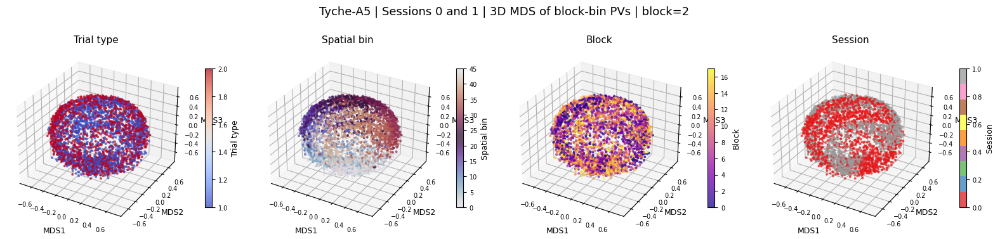

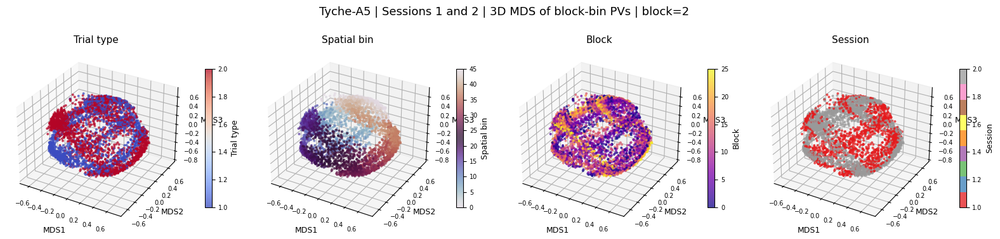

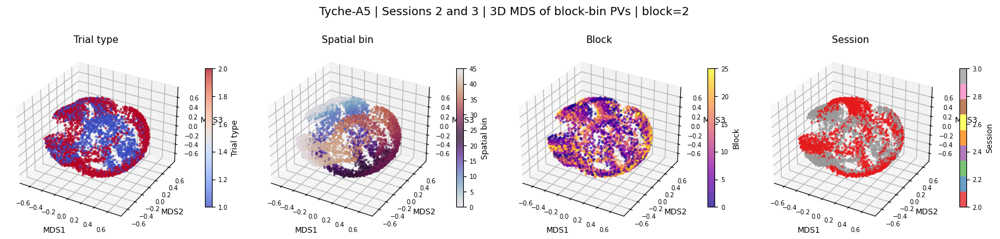

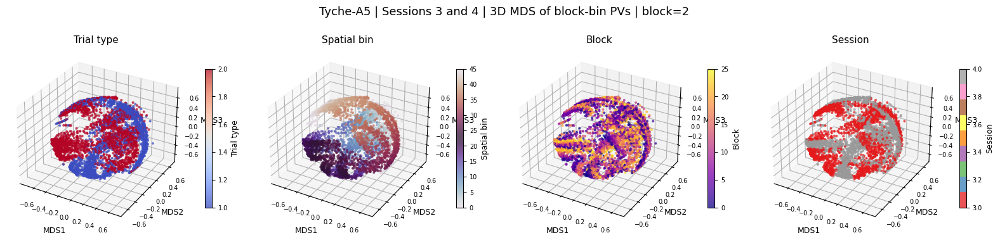

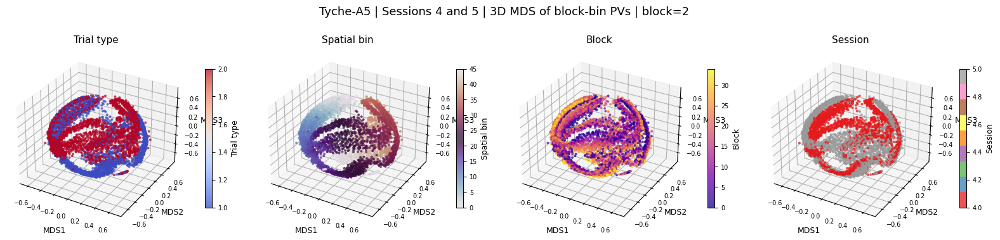

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# -------------------------------------------------------
# parameters
# -------------------------------------------------------

animal = animals[1]
ai = 1
data = Data_trial[animal]

block_size = 2
trial_types_to_include = [1, 2]
use_engaged = True

exclude = {
    0: [6, 7, 8],
    3: [6]
}

# -------------------------------------------------------
# helper functions
# -------------------------------------------------------

def build_block_bin_PVs_for_one_session(
    data,
    sess,
    trial_types_to_include=[1, 2],
    block_size=2,
    use_engaged=True
):
    """
    X_pv: samples x cells
    Y: samples x 4
       columns = trial_type, block_id, spatial_bin, session
    """

    PF_all = np.asarray(data["fields"][sess], float)
    tt_all = np.asarray(data["trial_types"][sess])

    X_list = []
    Y_list = []

    for trial_type in trial_types_to_include:

        idx = np.where(tt_all == trial_type)[0]
        PF = PF_all[idx]

        if use_engaged:
            engaged_trials = get_engaged_trials(PF, z_threshold=-2)
            PF = PF[engaged_trials]

        n_trials = PF.shape[0]

        if n_trials < block_size * 2:
            continue

        n_blocks = n_trials // block_size
        PF = PF[:n_blocks * block_size]

        PF_blocks = PF.reshape(
            n_blocks,
            block_size,
            PF.shape[1],
            PF.shape[2]
        )

        # blocks x cells x spatial bins
        PF_blocks = np.nanmean(PF_blocks, axis=1)

        n_blocks, n_cells, n_bins = PF_blocks.shape

        for b in range(n_blocks):
            for spatial_bin in range(n_bins):

                pv = PF_blocks[b, :, spatial_bin]

                X_list.append(pv)

                Y_list.append([
                    trial_type,
                    b,
                    spatial_bin,
                    sess
                ])

    if len(X_list) == 0:
        return None, None

    X_pv = np.asarray(X_list, float)
    Y = np.asarray(Y_list, int)

    X_pv = np.nan_to_num(X_pv)

    return X_pv, Y


def run_mds_from_pv_corr_3d(X_pv, random_state=0):

    R = np.corrcoef(X_pv)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)

    D = 1 - R
    D[D < 0] = 0

    mds = MDS(
        n_components=3,
        dissimilarity="precomputed",
        random_state=random_state,
        normalized_stress="auto"
    )

    emb = mds.fit_transform(D)

    return emb, R, D


# -------------------------------------------------------
# 1) compute and store pairwise session embeddings
# -------------------------------------------------------

pair_mds_results = {}

n_sessions = len(data["fields"])

valid_sessions = []

for sess in range(n_sessions):

    if ai in exclude and sess in exclude[ai]:
        continue

    valid_sessions.append(sess)

valid_sessions = sorted(valid_sessions)

for s1, s2 in zip(valid_sessions[:-1], valid_sessions[1:]):

    X1, Y1 = build_block_bin_PVs_for_one_session(
        data,
        s1,
        trial_types_to_include=trial_types_to_include,
        block_size=block_size,
        use_engaged=use_engaged
    )

    X2, Y2 = build_block_bin_PVs_for_one_session(
        data,
        s2,
        trial_types_to_include=trial_types_to_include,
        block_size=block_size,
        use_engaged=use_engaged
    )

    if X1 is None or X2 is None:
        print(f"{animal} | S{s1}-S{s2}: skipped")
        continue

    X_pair = np.vstack([X1, X2])
    Y_pair = np.vstack([Y1, Y2])

    if X_pair.shape[0] < 10:
        print(f"{animal} | S{s1}-S{s2}: too few PVs")
        continue

    emb, R, D = run_mds_from_pv_corr_3d(
        X_pair,
        random_state=0
    )

    pair_mds_results[(s1, s2)] = {
        "X_pv": X_pair,
        "Y": Y_pair,
        "emb": emb,
        "R": R,
        "D": D
    }

    print(
        f"{animal} | S{s1}-S{s2}: "
        f"X={X_pair.shape}, emb={emb.shape}"
    )


# -------------------------------------------------------
# 2) visualize separately: 1 x 4 per session pair, 3D
# -------------------------------------------------------

for (s1, s2), res in pair_mds_results.items():

    emb = res["emb"]
    Y = res["Y"]

    trial_type_vals = Y[:, 0]
    block_vals = Y[:, 1]
    spatial_bin_vals = Y[:, 2]
    session_vals = Y[:, 3]

    fig = plt.figure(figsize=(16, 4))

    plot_info = [
        (trial_type_vals, "Trial type", "coolwarm"),
        (spatial_bin_vals, "Spatial bin", "twilight"),
        (block_vals, "Block", "plasma"),
        (session_vals, "Session", "Set1")
    ]

    for i, (cvals, title, cmap) in enumerate(plot_info):

        ax = fig.add_subplot(1, 4, i + 1, projection="3d")

        sc = ax.scatter(
            emb[:, 0],
            emb[:, 1],
            emb[:, 2],
            c=cvals,
            cmap=cmap,
            s=8,
            alpha=0.75,
            linewidths=0
        )

        ax.set_title(title, fontsize=11)

        ax.set_xlabel("MDS1", fontsize=9)
        ax.set_ylabel("MDS2", fontsize=9)
        ax.set_zlabel("MDS3", fontsize=9)

        ax.tick_params(labelsize=7)

        cbar = fig.colorbar(
            sc,
            ax=ax,
            shrink=0.65,
            pad=0.08
        )

        cbar.set_label(title, fontsize=9)
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f"{animal} | Sessions {s1} and {s2} | 3D MDS of block-bin PVs | block={block_size}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

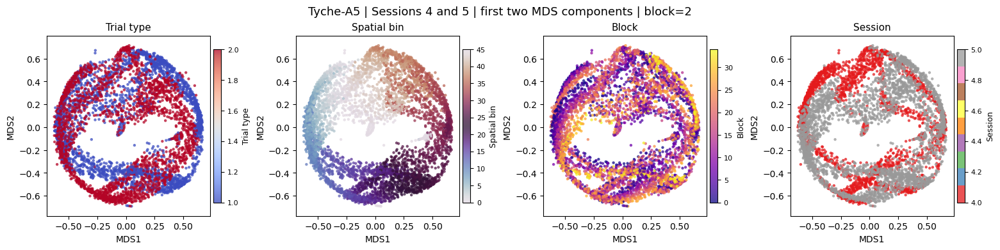

In [81]:
# get last session-pair result
last_pair = sorted(pair_mds_results.keys())[-1]
res = pair_mds_results[last_pair]

s1, s2 = last_pair

emb = res["emb"]
Y = res["Y"]

trial_type_vals = Y[:, 0]
block_vals = Y[:, 1]
spatial_bin_vals = Y[:, 2]
session_vals = Y[:, 3]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(15.5, 3.8),
    constrained_layout=True
)

plot_info = [
    (trial_type_vals, "Trial type", "coolwarm"),
    (spatial_bin_vals, "Spatial bin", "twilight"),
    (block_vals, "Block", "plasma"),
    (session_vals, "Session", "Set1")
]

for ax, (cvals, title, cmap) in zip(axes, plot_info):

    sc = ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=cvals,
        cmap=cmap,
        s=10,
        alpha=0.75,
        linewidths=0
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("MDS1")
    ax.set_ylabel("MDS2")
    ax.set_aspect("equal", adjustable="datalim")

    cbar = fig.colorbar(
        sc,
        ax=ax,
        shrink=0.85,
        pad=0.02
    )
    cbar.set_label(title, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    f"{animal} | Sessions {s1} and {s2} | first two MDS components | block={block_size}",
    fontsize=13
)

plt.show()

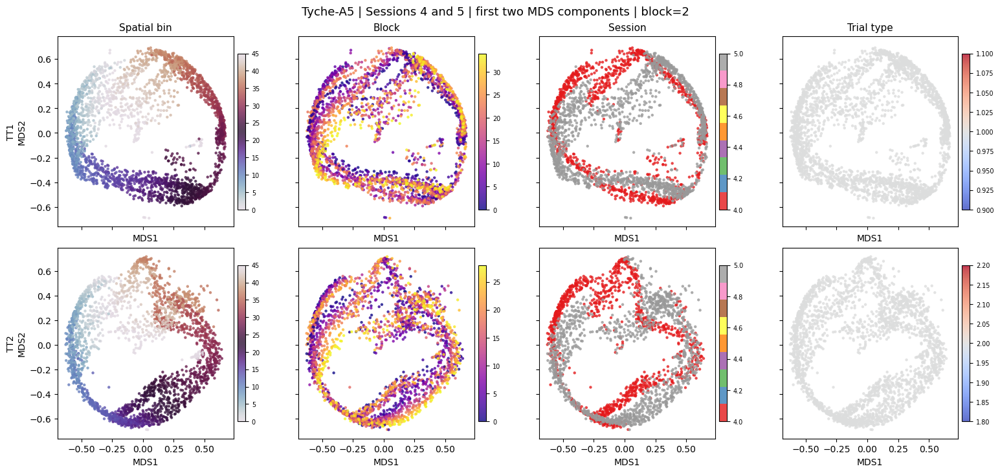

In [83]:
# get last session-pair result
last_pair = sorted(pair_mds_results.keys())[-1]
res = pair_mds_results[last_pair]

s1, s2 = last_pair

emb = res["emb"]
Y = res["Y"]

trial_type_vals = Y[:, 0]
block_vals = Y[:, 1]
spatial_bin_vals = Y[:, 2]
session_vals = Y[:, 3]

# -------------------------------------------------------
# plot: 2 rows = TT1 / TT2
# -------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15.5, 7.2),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

plot_info = [
    (spatial_bin_vals, "Spatial bin", "twilight"),
    (block_vals, "Block", "plasma"),
    (session_vals, "Session", "Set1"),
    (trial_type_vals, "Trial type", "coolwarm")
]

for row, tt in enumerate([1, 2]):

    mask = trial_type_vals == tt

    emb_tt = emb[mask]

    for col, (cvals, title, cmap) in enumerate(plot_info):

        ax = axes[row, col]

        sc = ax.scatter(
            emb_tt[:, 0],
            emb_tt[:, 1],
            c=cvals[mask],
            cmap=cmap,
            s=10,
            alpha=0.8,
            linewidths=0
        )

        if row == 0:
            ax.set_title(title, fontsize=11)

        if col == 0:
            ax.set_ylabel(f"TT{tt}\nMDS2", fontsize=10)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("MDS1", fontsize=10)

        ax.set_aspect("equal", adjustable="box")

        cbar = fig.colorbar(
            sc,
            ax=ax,
            shrink=0.82,
            pad=0.02
        )

        cbar.ax.tick_params(labelsize=7)

fig.suptitle(
    f"{animal} | Sessions {s1} and {s2} | first two MDS components | block={block_size}",
    fontsize=13
)

plt.show()

In [95]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# -----------------------------
# parameters
# -----------------------------

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

animal = animals[1]
data = Data_trial[animal]

sessions_to_use = [4, 5]
block_size = 1
trial_types_to_include = [1, 2]
use_engaged = True

# -----------------------------
# helpers
# -----------------------------

def build_block_bin_PVs_for_one_session(
    data,
    sess,
    trial_types_to_include=[1, 2],
    block_size=1,
    use_engaged=True
):

    PF_all = np.asarray(data["fields"][sess], float)
    tt_all = np.asarray(data["trial_types"][sess])

    X_list = []
    Y_list = []

    for trial_type in trial_types_to_include:

        idx = np.where(tt_all == trial_type)[0]
        PF = PF_all[idx]

        if use_engaged:
            engaged_trials = get_engaged_trials(PF, z_threshold=-2)
            PF = PF[engaged_trials]

        n_trials = PF.shape[0]

        if n_trials < block_size * 2:
            continue

        n_blocks = n_trials // block_size
        PF = PF[:n_blocks * block_size]

        PF_blocks = PF.reshape(
            n_blocks,
            block_size,
            PF.shape[1],
            PF.shape[2]
        )

        PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins

        n_blocks, n_cells, n_bins = PF_blocks.shape

        for b in range(n_blocks):
            for spatial_bin in range(n_bins):

                X_list.append(PF_blocks[b, :, spatial_bin])

                Y_list.append([
                    trial_type,
                    b,
                    spatial_bin,
                    sess
                ])

    if len(X_list) == 0:
        return None, None

    X = np.asarray(X_list, float)
    Y = np.asarray(Y_list, int)

    X = np.nan_to_num(X)

    return X, Y


def run_mds_2d_from_corr(X, random_state=0):

    R = np.corrcoef(X)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)

    D = 1 - R
    D[D < 0] = 0

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=random_state,
        normalized_stress="auto"
    )

    emb = mds.fit_transform(D)

    return emb, R, D


# -----------------------------
# compute sessions 4 and 5 together
# -----------------------------

X_all = []
Y_all = []

for sess in sessions_to_use:

    X, Y = build_block_bin_PVs_for_one_session(
        data,
        sess,
        trial_types_to_include=trial_types_to_include,
        block_size=block_size,
        use_engaged=use_engaged
    )

    if X is None:
        print(f"{animal} | S{sess}: skipped")
        continue

    X_all.append(X)
    Y_all.append(Y)

X_all = np.vstack(X_all)
Y_all = np.vstack(Y_all)

emb, R, D = run_mds_2d_from_corr(X_all, random_state=0)

print(f"{animal} | sessions {sessions_to_use}: X={X_all.shape}, emb={emb.shape}")


/tmp/ipykernel_23211/3434538848.py:63: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | sessions [4, 5]: X=(10718, 4254), emb=(10718, 2)


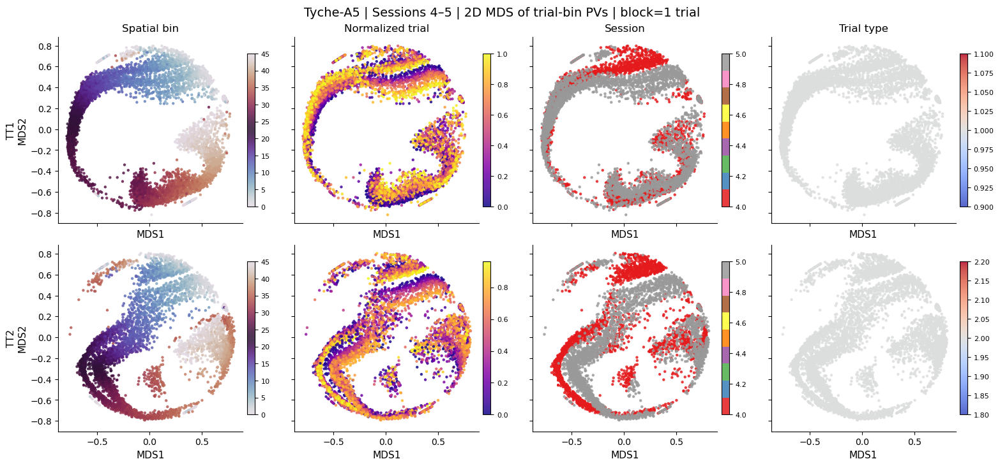

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_sessions4_5_MDS_2D_trial_bin_PVs_block1.pdf
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_sessions4_5_MDS_2D_trial_bin_PVs_block1.png


In [85]:

trial_vals_norm = np.zeros_like(trial_vals, dtype=float)

for sess in np.unique(session_vals):

    mask_sess = session_vals == sess

    vals = trial_vals[mask_sess].astype(float)

    if len(np.unique(vals)) > 1:

        vals_norm = (
            (vals - vals.min())
            / (vals.max() - vals.min())
        )

    else:
        vals_norm = np.zeros_like(vals)

    trial_vals_norm[mask_sess] = vals_norm

# -----------------------------
# plot: 2 rows = TT1 / TT2, 4 columns = features
# -----------------------------

trial_type_vals = Y_all[:, 0]
trial_vals = Y_all[:, 1]
spatial_bin_vals = Y_all[:, 2]
session_vals = Y_all[:, 3]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15.5, 7.2),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

plot_info = [
    (spatial_bin_vals, "Spatial bin", "twilight"),
    (trial_vals_norm, "Normalized trial", "plasma"),
    (session_vals, "Session", "Set1"),
    (trial_type_vals, "Trial type", "coolwarm")
]

for row, tt in enumerate([1, 2]):

    mask = trial_type_vals == tt
    emb_tt = emb[mask]

    for col, (cvals, title, cmap) in enumerate(plot_info):

        ax = axes[row, col]

        sc = ax.scatter(
            emb_tt[:, 0],
            emb_tt[:, 1],
            c=cvals[mask],
            cmap=cmap,
            s=10,
            alpha=0.85,
            linewidths=0
        )

        if row == 0:
            ax.set_title(title, fontsize=12)

        if col == 0:
            ax.set_ylabel(f"TT{tt}\nMDS2", fontsize=11)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("MDS1", fontsize=11)
        ax.set_aspect("equal", adjustable="box")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        cbar = fig.colorbar(
            sc,
            ax=ax,
            shrink=0.82,
            pad=0.02
        )
        cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    f"{animal} | Sessions 4–5 | 2D MDS of trial-bin PVs | block={block_size} trial",
    fontsize=14
)

pdf_path = os.path.join(
    save_dir,
    f"{animal}_sessions4_5_MDS_2D_trial_bin_PVs_block{block_size}.pdf"
)

png_path = os.path.join(save_dir, f"{animal}_sessions4_5_MDS_2D_trial_bin_PVs_block{block_size}.png")

fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")

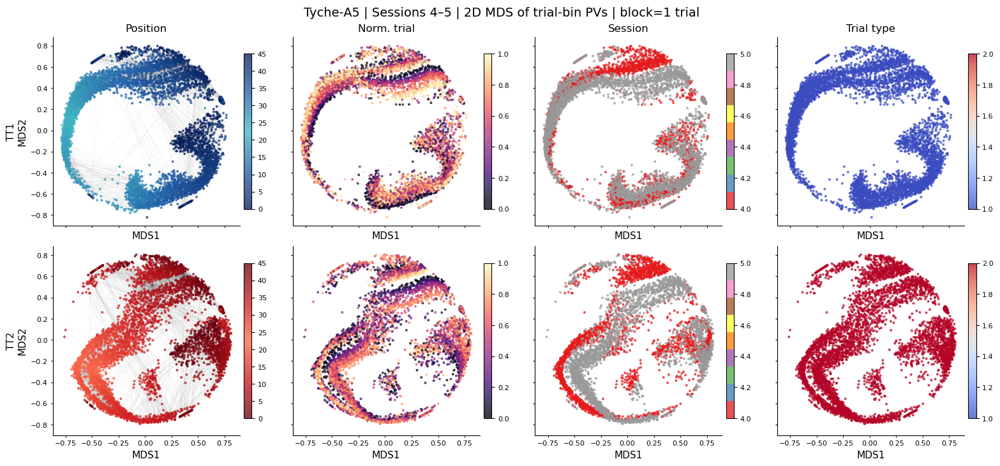

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_sessions4_5_MDS_2D_trial_bin_PVs_custom_block1.pdf
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_sessions4_5_MDS_2D_trial_bin_PVs_custom_block1.png


In [96]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import numpy as np
import os

# -------------------------------------------------------
# custom cyclic-ish position colormaps
# -------------------------------------------------------

cmap_tt1_pos = LinearSegmentedColormap.from_list(
    "tt1_position_blue_cyclic",
    [
        (0.00, "#081d58"),
        (0.25, "#225ea8"),
        (0.50, "#41b6c4"),
        (0.75, "#225ea8"),
        (1.00, "#081d58")
    ]
)

cmap_tt2_pos = LinearSegmentedColormap.from_list(
    "tt2_position_red_cyclic",
    [
        (0.00, "#67000d"),
        (0.25, "#cb181d"),
        (0.50, "#fb6a4a"),
        (0.75, "#cb181d"),
        (1.00, "#67000d")
    ]
)

cmap_trial = "magma"

# -------------------------------------------------------
# metadata
# -------------------------------------------------------

trial_type_vals = Y_all[:, 0]
trial_vals = Y_all[:, 1]
spatial_bin_vals = Y_all[:, 2]
session_vals = Y_all[:, 3]

# normalize trial number within each session
trial_vals_norm = np.zeros_like(trial_vals, dtype=float)

for sess in np.unique(session_vals):

    mask_sess = session_vals == sess
    vals = trial_vals[mask_sess].astype(float)

    if len(np.unique(vals)) > 1:
        trial_vals_norm[mask_sess] = (
            (vals - vals.min())
            / (vals.max() - vals.min())
        )
    else:
        trial_vals_norm[mask_sess] = 0

# shared spatial scale
spatial_vmin = np.nanmin(spatial_bin_vals)
spatial_vmax = np.nanmax(spatial_bin_vals)

# -------------------------------------------------------
# plot: 2 rows = TT1 / TT2, 4 columns = features
# -------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15.5, 7.2),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for row, tt in enumerate([1, 2]):

    mask_tt = trial_type_vals == tt
    emb_tt = emb[mask_tt]

    # choose TT-specific position cmap
    pos_cmap = cmap_tt1_pos if tt == 1 else cmap_tt2_pos

    plot_info = [
        (spatial_bin_vals, "Position", pos_cmap, spatial_vmin, spatial_vmax),
        (trial_vals_norm, "Norm. trial", cmap_trial, 0, 1),
        (session_vals, "Session", "Set1", np.nanmin(session_vals), np.nanmax(session_vals)),
        (trial_type_vals, "Trial type", "coolwarm", 1, 2)
    ]

    for col, (cvals, title, cmap, vmin, vmax) in enumerate(plot_info):

        ax = axes[row, col]

        # faint trajectories only for position panel
        if col == 0:
            for tr in np.unique(trial_vals[mask_tt]):

                mt = mask_tt & (trial_vals == tr)

                if np.sum(mt) < 2:
                    continue

                order_line = np.argsort(spatial_bin_vals[mt])

                ax.plot(
                    emb[mt, 0][order_line],
                    emb[mt, 1][order_line],
                    color="black",
                    lw=0.25,
                    alpha=0.08,
                    zorder=1
                )

            order = np.argsort(spatial_bin_vals[mask_tt])

        else:
            order = np.arange(np.sum(mask_tt))

        sc = ax.scatter(
            emb_tt[:, 0][order],
            emb_tt[:, 1][order],
            c=cvals[mask_tt][order],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            s=8,
            alpha=0.76,
            linewidths=0,
            zorder=2
        )

        if row == 0:
            ax.set_title(title, fontsize=12)

        if col == 0:
            ax.set_ylabel(f"TT{tt}\nMDS2", fontsize=11)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("MDS1", fontsize=11)
        ax.set_aspect("equal", adjustable="box")

        ax.tick_params(labelsize=8, length=2, width=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        cbar = fig.colorbar(
            sc,
            ax=ax,
            shrink=0.82,
            pad=0.02
        )
        cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    f"{animal} | Sessions 4–5 | 2D MDS of trial-bin PVs | block={block_size} trial",
    fontsize=14
)

pdf_path = os.path.join(
    save_dir,
    f"{animal}_sessions4_5_MDS_2D_trial_bin_PVs_custom_block{block_size}.pdf"
)

png_path = os.path.join(
    save_dir,
    f"{animal}_sessions4_5_MDS_2D_trial_bin_PVs_custom_block{block_size}.png"
)

fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")

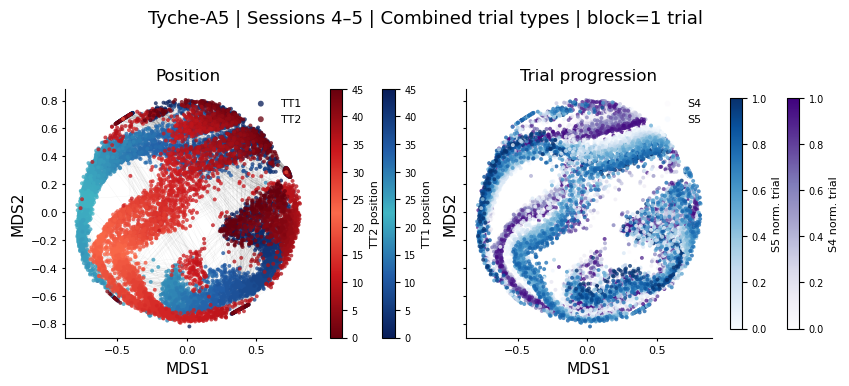

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_sessions4_5_MDS_2D_combinedTT_custom_block1.pdf
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_sessions4_5_MDS_2D_combinedTT_custom_block1.png


In [98]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import numpy as np
import os

# -------------------------------------------------------
# custom cyclic-ish position colormaps
# -------------------------------------------------------

cmap_tt1_pos = LinearSegmentedColormap.from_list(
    "tt1_position_blue_cyclic",
    [
        (0.00, "#081d58"),
        (0.25, "#225ea8"),
        (0.50, "#41b6c4"),
        (0.75, "#225ea8"),
        (1.00, "#081d58")
    ]
)

cmap_tt2_pos = LinearSegmentedColormap.from_list(
    "tt2_position_red_cyclic",
    [
        (0.00, "#67000d"),
        (0.25, "#cb181d"),
        (0.50, "#fb6a4a"),
        (0.75, "#cb181d"),
        (1.00, "#67000d")
    ]
)

# trial progression cmap per session
session_trial_cmaps = {
    4: "Purples",
    5: "Blues"
}

default_session_cmaps = ["Purples", "Blues", "Greens", "Oranges"]

# -------------------------------------------------------
# metadata
# -------------------------------------------------------

trial_type_vals = Y_all[:, 0]
trial_vals = Y_all[:, 1]
spatial_bin_vals = Y_all[:, 2]
session_vals = Y_all[:, 3]

# normalize trial number within each session
trial_vals_norm = np.zeros_like(trial_vals, dtype=float)

for sess in np.unique(session_vals):

    mask_sess = session_vals == sess
    vals = trial_vals[mask_sess].astype(float)

    if len(np.unique(vals)) > 1:

        trial_vals_norm[mask_sess] = (
            (vals - vals.min())
            / (vals.max() - vals.min())
        )

    else:

        trial_vals_norm[mask_sess] = 0

# shared spatial scale
spatial_vmin = np.nanmin(spatial_bin_vals)
spatial_vmax = np.nanmax(spatial_bin_vals)

# -------------------------------------------------------
# figure
# -------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.4, 3.9),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

# =======================================================
# Panel 1: position
# =======================================================

ax = axes[0]

for tt, cmap, label in zip(
    [1, 2],
    [cmap_tt1_pos, cmap_tt2_pos],
    ["TT1", "TT2"]
):

    mask_tt = trial_type_vals == tt

    # ---------------------------------------------------
    # faint trajectories
    # ---------------------------------------------------

    for sess in np.unique(session_vals):

        mask_st = mask_tt & (session_vals == sess)

        for tr in np.unique(trial_vals[mask_st]):

            mt = mask_st & (trial_vals == tr)

            if np.sum(mt) < 2:
                continue

            order_line = np.argsort(spatial_bin_vals[mt])

            ax.plot(
                emb[mt, 0][order_line],
                emb[mt, 1][order_line],
                color="black",
                lw=0.25,
                alpha=0.06,
                zorder=1
            )

    # ---------------------------------------------------
    # scatter
    # ---------------------------------------------------

    order = np.argsort(spatial_bin_vals[mask_tt])

    ax.scatter(
        emb[mask_tt, 0][order],
        emb[mask_tt, 1][order],
        c=spatial_bin_vals[mask_tt][order],
        cmap=cmap,
        vmin=spatial_vmin,
        vmax=spatial_vmax,
        s=8,
        alpha=0.76,
        linewidths=0,
        label=label,
        zorder=2
    )

ax.set_title("Position", fontsize=12)

ax.set_xlabel("MDS1", fontsize=11)
ax.set_ylabel("MDS2", fontsize=11)

ax.set_aspect("equal", adjustable="box")

ax.legend(
    frameon=False,
    fontsize=8,
    loc="best",
    markerscale=1.5
)

# separate colorbars
sm1 = plt.cm.ScalarMappable(
    cmap=cmap_tt1_pos,
    norm=plt.Normalize(spatial_vmin, spatial_vmax)
)

sm2 = plt.cm.ScalarMappable(
    cmap=cmap_tt2_pos,
    norm=plt.Normalize(spatial_vmin, spatial_vmax)
)

cbar1 = fig.colorbar(
    sm1,
    ax=ax,
    shrink=0.70,
    pad=0.01
)

cbar1.set_label("TT1 position", fontsize=8)
cbar1.ax.tick_params(labelsize=7)

cbar2 = fig.colorbar(
    sm2,
    ax=ax,
    shrink=0.70,
    pad=0.075
)

cbar2.set_label("TT2 position", fontsize=8)
cbar2.ax.tick_params(labelsize=7)

# =======================================================
# Panel 2: trial progression
# =======================================================

ax = axes[1]

for si, sess in enumerate(np.unique(session_vals)):

    mask_sess = session_vals == sess

    cmap = session_trial_cmaps.get(
        sess,
        default_session_cmaps[si % len(default_session_cmaps)]
    )

    ax.scatter(
        emb[mask_sess, 0],
        emb[mask_sess, 1],
        c=trial_vals_norm[mask_sess],
        cmap=cmap,
        vmin=0,
        vmax=1,
        s=8,
        alpha=0.78,
        linewidths=0,
        label=f"S{sess}",
        zorder=2
    )

ax.set_title("Trial progression", fontsize=12)

ax.set_xlabel("MDS1", fontsize=11)
ax.set_ylabel("MDS2", fontsize=11)

ax.set_aspect("equal", adjustable="box")

ax.legend(
    frameon=False,
    fontsize=8,
    loc="best",
    markerscale=1.5
)

# separate colorbars for sessions
for si, sess in enumerate(np.unique(session_vals)):

    cmap = session_trial_cmaps.get(
        sess,
        default_session_cmaps[si % len(default_session_cmaps)]
    )

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(0, 1)
    )

    cbar = fig.colorbar(
        sm,
        ax=ax,
        shrink=0.65,
        pad=0.02 + 0.055 * si
    )

    cbar.set_label(
        f"S{sess} norm. trial",
        fontsize=8
    )

    cbar.ax.tick_params(labelsize=7)

# -------------------------------------------------------
# styling
# -------------------------------------------------------

for ax in axes:

    ax.tick_params(
        labelsize=8,
        length=2,
        width=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    f"{animal} | Sessions 4–5 | Combined trial types | block={block_size} trial",
    fontsize=13
)

# -------------------------------------------------------
# save
# -------------------------------------------------------

pdf_path = os.path.join(
    save_dir,
    f"{animal}_sessions4_5_MDS_2D_combinedTT_custom_block{block_size}.pdf"
)

png_path = os.path.join(
    save_dir,
    f"{animal}_sessions4_5_MDS_2D_combinedTT_custom_block{block_size}.png"
)

fig.savefig(
    pdf_path,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")

/tmp/ipykernel_23211/1687582712.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S0: X=(3358, 4254), emb=(3358, 2)


/tmp/ipykernel_23211/1687582712.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S1: X=(3082, 4254), emb=(3082, 2)


/tmp/ipykernel_23211/1687582712.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


...

Tyche-A5 | S3: X=(4002, 4254), emb=(4002, 2)


/tmp/ipykernel_23211/1687582712.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S4: X=(4784, 4254), emb=(4784, 2)


/tmp/ipykernel_23211/1687582712.py:70: RuntimeWarning: Mean of empty slice
  PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mohammad/anaconda3/envs/vr2p/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Tyche-A5 | S5: X=(5934, 4254), emb=(5934, 2)


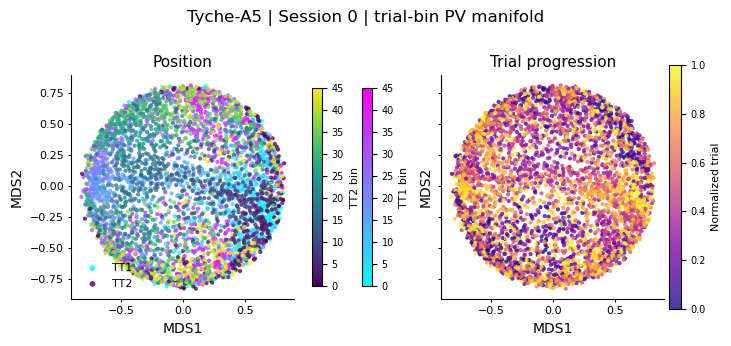

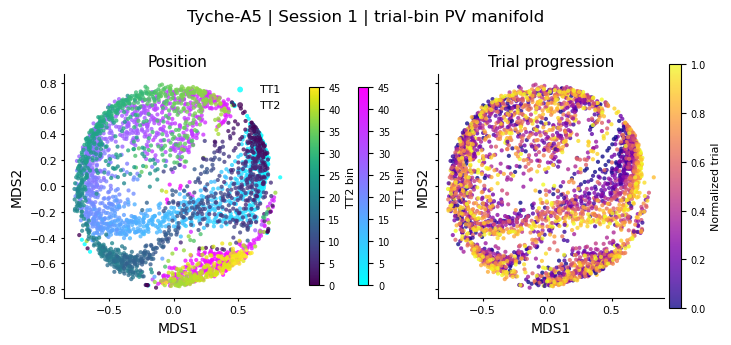

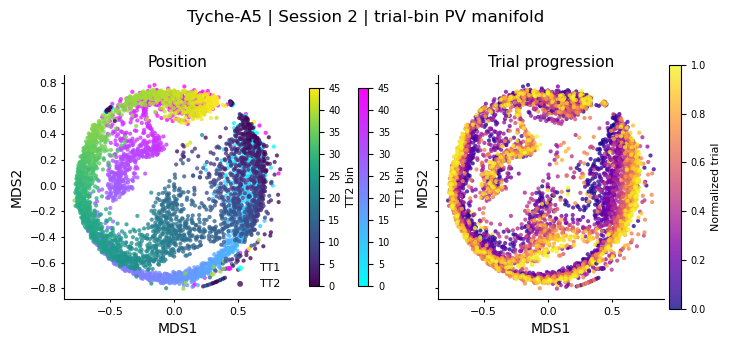

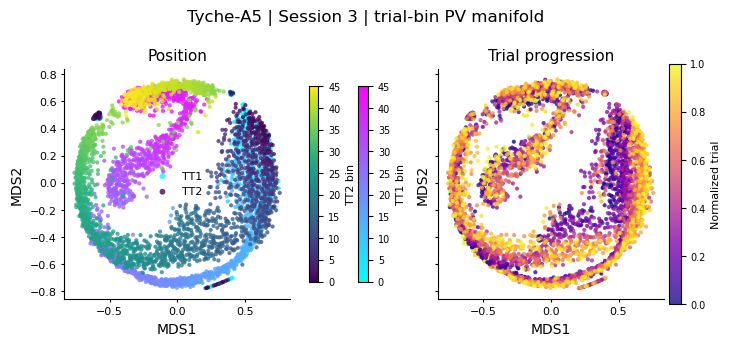

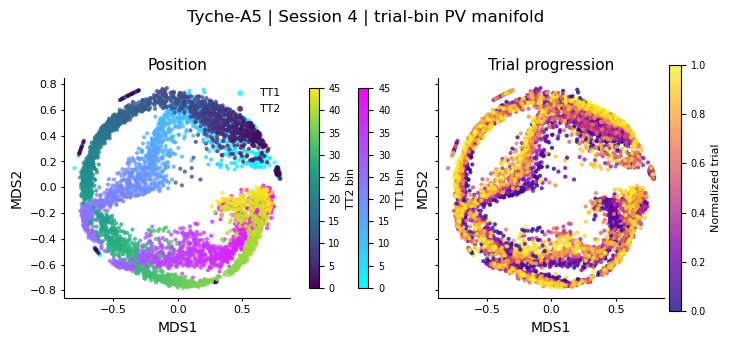

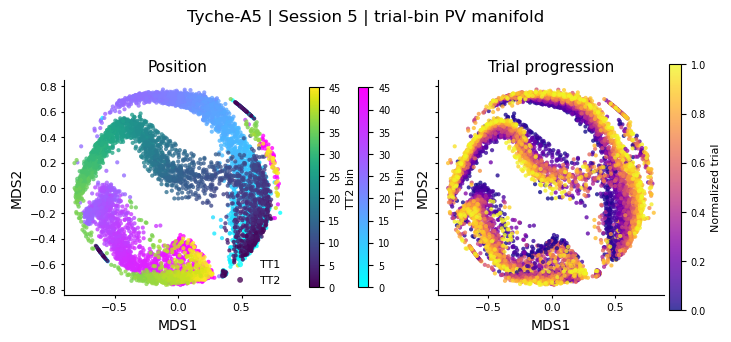

Saved multi-page PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_all_sessions_MDS_2D_position_trial_block1.pdf


In [86]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from matplotlib.backends.backend_pdf import PdfPages

# -------------------------------------------------------
# parameters
# -------------------------------------------------------

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

animal = animals[1]
data = Data_trial[animal]

block_size = 1
trial_types_to_include = [1, 2]
use_engaged = True

# -------------------------------------------------------
# helpers
# -------------------------------------------------------

def build_session_trial_bin_PVs(
    data,
    sess,
    trial_types_to_include=[1, 2],
    block_size=1,
    use_engaged=True
):
    """
    Returns:
        X : samples x cells
        Y : samples x 4
            columns = trial_type, trial/block number, spatial_bin, session
    """

    PF_all = np.asarray(data["fields"][sess], float)
    tt_all = np.asarray(data["trial_types"][sess])

    X_list = []
    Y_list = []

    for trial_type in trial_types_to_include:

        idx = np.where(tt_all == trial_type)[0]
        PF = PF_all[idx]

        if use_engaged:
            engaged_trials = get_engaged_trials(PF, z_threshold=-2)
            PF = PF[engaged_trials]

        n_trials = PF.shape[0]

        if n_trials < block_size * 2:
            continue

        n_blocks = n_trials // block_size
        PF = PF[:n_blocks * block_size]

        PF_blocks = PF.reshape(
            n_blocks,
            block_size,
            PF.shape[1],
            PF.shape[2]
        )

        # block_size=1 means trial-level PVs
        PF_blocks = np.nanmean(PF_blocks, axis=1)  # blocks x cells x bins

        n_blocks, n_cells, n_bins = PF_blocks.shape

        for b in range(n_blocks):
            for spatial_bin in range(n_bins):

                X_list.append(PF_blocks[b, :, spatial_bin])

                Y_list.append([
                    trial_type,
                    b,
                    spatial_bin,
                    sess
                ])

    if len(X_list) == 0:
        return None, None

    X = np.asarray(X_list, float)
    Y = np.asarray(Y_list, int)

    X = np.nan_to_num(X)

    return X, Y


def run_mds_2d_from_corr(X, random_state=0):

    R = np.corrcoef(X)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0)

    D = 1 - R
    D[D < 0] = 0

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=random_state,
        normalized_stress="auto"
    )

    emb = mds.fit_transform(D)

    return emb, R, D


# -------------------------------------------------------
# compute first, store results
# -------------------------------------------------------

session_mds_results = {}

n_sessions = len(data["fields"])

for sess in range(n_sessions):

    X, Y = build_session_trial_bin_PVs(
        data,
        sess,
        trial_types_to_include=trial_types_to_include,
        block_size=block_size,
        use_engaged=use_engaged
    )

    if X is None or X.shape[0] < 10:
        print(f"{animal} | S{sess}: skipped")
        continue

    emb, R, D = run_mds_2d_from_corr(X, random_state=0)

    session_mds_results[sess] = {
        "X": X,
        "Y": Y,
        "emb": emb,
        "R": R,
        "D": D
    }

    print(f"{animal} | S{sess}: X={X.shape}, emb={emb.shape}")


# -------------------------------------------------------
# visualization helper
# -------------------------------------------------------

def plot_session_mds_two_panels(
    sess,
    res,
    animal,
    save_dir=None,
    save=True
):

    emb = res["emb"]
    Y = res["Y"]

    trial_type_vals = Y[:, 0]
    trial_vals = Y[:, 1]
    spatial_bin_vals = Y[:, 2]

    # normalize trial number separately for each trial type
    trial_vals_norm = np.zeros_like(trial_vals, dtype=float)

    for tt in np.unique(trial_type_vals):

        m = trial_type_vals == tt
        vals = trial_vals[m].astype(float)

        if len(np.unique(vals)) > 1:
            trial_vals_norm[m] = (vals - vals.min()) / (vals.max() - vals.min())
        else:
            trial_vals_norm[m] = 0

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 3.4),
        constrained_layout=True,
        sharex=True,
        sharey=True
    )

    # ---------------------------------------------------
    # Panel 1: spatial position, TT1 and TT2 in same panel
    # ---------------------------------------------------

    ax = axes[0]

    for tt, cmap, label in zip([1, 2], ["cool", "viridis"], ["TT1", "TT2"]):

        m = trial_type_vals == tt

        sc = ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=spatial_bin_vals[m],
            cmap=cmap,
            s=9,
            alpha=0.78,
            linewidths=0,
            label=label
        )

    ax.set_title("Position", fontsize=11)
    ax.set_xlabel("MDS1")
    ax.set_ylabel("MDS2")
    ax.set_aspect("equal", adjustable="box")

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="best",
        markerscale=1.4
    )

    # add two compact colorbars
    m1 = trial_type_vals == 1
    m2 = trial_type_vals == 2

    sc1 = ax.scatter([], [], c=[], cmap="cool")
    sc2 = ax.scatter([], [], c=[], cmap="viridis")

    norm_min = np.nanmin(spatial_bin_vals)
    norm_max = np.nanmax(spatial_bin_vals)

    sm1 = plt.cm.ScalarMappable(
        cmap="cool",
        norm=plt.Normalize(norm_min, norm_max)
    )
    sm2 = plt.cm.ScalarMappable(
        cmap="viridis",
        norm=plt.Normalize(norm_min, norm_max)
    )

    cbar1 = fig.colorbar(sm1, ax=ax, shrink=0.65, pad=0.01)
    cbar1.set_label("TT1 bin", fontsize=8)
    cbar1.ax.tick_params(labelsize=7)

    cbar2 = fig.colorbar(sm2, ax=ax, shrink=0.65, pad=0.08)
    cbar2.set_label("TT2 bin", fontsize=8)
    cbar2.ax.tick_params(labelsize=7)

    # ---------------------------------------------------
    # Panel 2: normalized trial number
    # ---------------------------------------------------

    ax = axes[1]

    sc = ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=trial_vals_norm,
        cmap="plasma",
        s=9,
        alpha=0.78,
        linewidths=0
    )

    ax.set_title("Trial progression", fontsize=11)
    ax.set_xlabel("MDS1")
    ax.set_ylabel("MDS2")
    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Normalized trial", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # ---------------------------------------------------
    # styling
    # ---------------------------------------------------

    for ax in axes:
        ax.tick_params(labelsize=8, length=2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{animal} | Session {sess} | trial-bin PV manifold",
        fontsize=12
    )

    if save and save_dir is not None:

        pdf_path = os.path.join(
            save_dir,
            f"{animal}_S{sess}_MDS_2D_position_trial_block{block_size}.pdf"
        )

        png_path = os.path.join(
            save_dir,
            f"{animal}_S{sess}_MDS_2D_position_trial_block{block_size}.png"
        )

        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
        fig.savefig(png_path, dpi=300, bbox_inches="tight")

    return fig, axes


# -------------------------------------------------------
# plot and save each session into separate files
# -------------------------------------------------------

for sess, res in session_mds_results.items():

    fig, axes = plot_session_mds_two_panels(
        sess,
        res,
        animal=animal,
        save_dir=save_dir,
        save=True
    )

    plt.show()


# -------------------------------------------------------
# also save all sessions into one multi-page PDF
# -------------------------------------------------------

multi_pdf_path = os.path.join(
    save_dir,
    f"{animal}_all_sessions_MDS_2D_position_trial_block{block_size}.pdf"
)

with PdfPages(multi_pdf_path) as pdf:

    for sess, res in session_mds_results.items():

        fig, axes = plot_session_mds_two_panels(
            sess,
            res,
            animal=animal,
            save_dir=None,
            save=False
        )

        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.close(fig)

print(f"Saved multi-page PDF:\n{multi_pdf_path}")

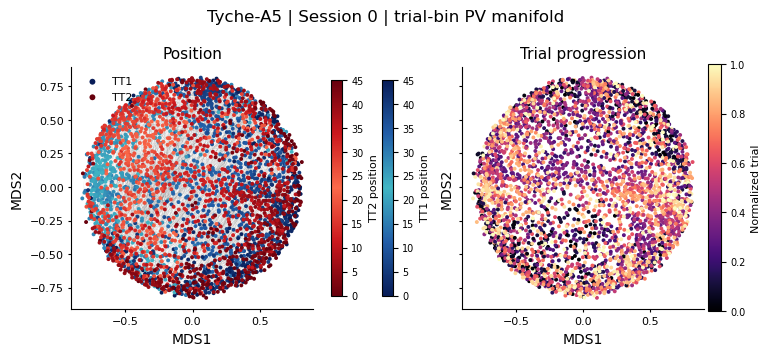

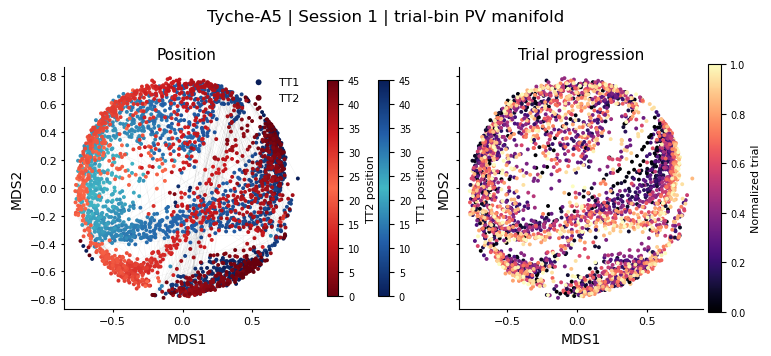

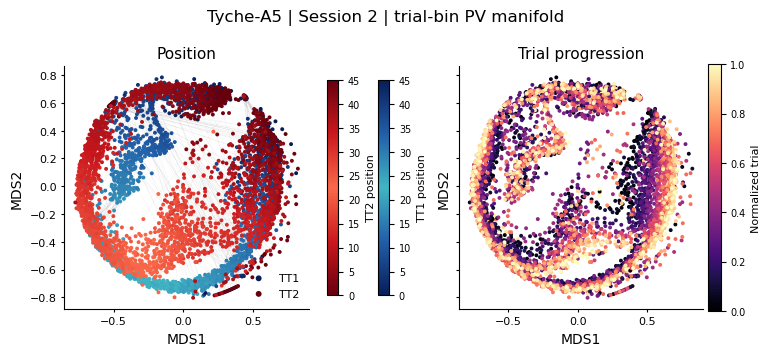

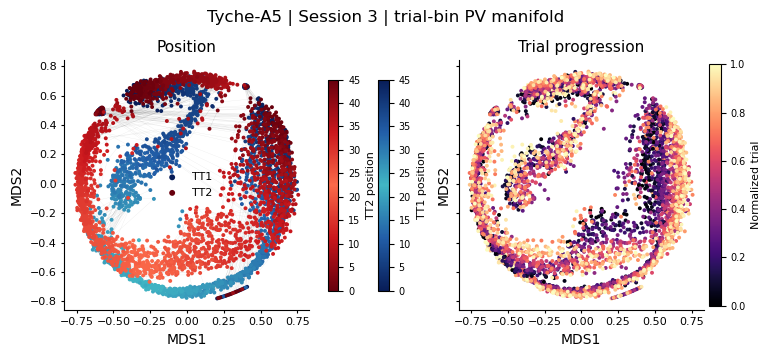

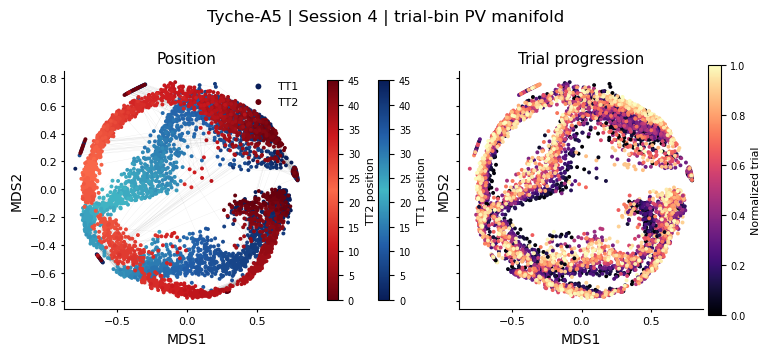

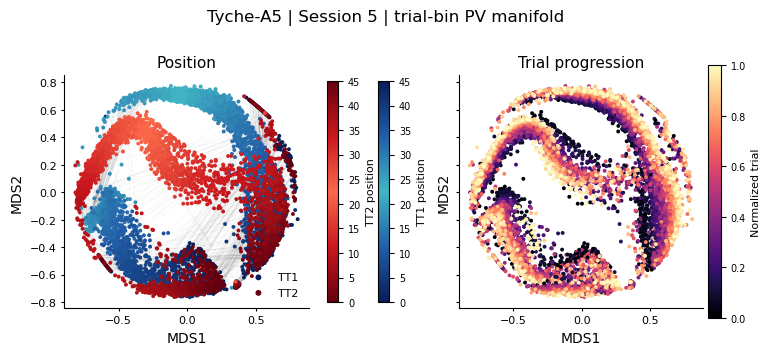

In [91]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import os
import numpy as np

# -------------------------------------------------------
# improved cyclic-ish position colormaps
# dark -> bright -> dark, clearer than white -> color -> white
# -------------------------------------------------------

cmap_tt1_pos = LinearSegmentedColormap.from_list(
    "tt1_position_blue_cyclic",
    [
        (0.00, "#081d58"),
        (0.25, "#225ea8"),
        (0.50, "#41b6c4"),
        (0.75, "#225ea8"),
        (1.00, "#081d58")
    ]
)

cmap_tt2_pos = LinearSegmentedColormap.from_list(
    "tt2_position_red_cyclic",
    [
        (0.00, "#67000d"),
        (0.25, "#cb181d"),
        (0.50, "#fb6a4a"),
        (0.75, "#cb181d"),
        (1.00, "#67000d")
    ]
)

# trial-progression cmap
cmap_trial = "magma"
# alternatives: "inferno", "cividis", "plasma"


# -------------------------------------------------------
# plotting function
# -------------------------------------------------------

def plot_session_mds_two_panels(
    sess,
    res,
    animal,
    save_dir=None,
    save=True,
    draw_trajectories=True
):

    emb = res["emb"]
    Y = res["Y"]

    trial_type_vals = Y[:, 0]
    trial_vals = Y[:, 1]
    spatial_bin_vals = Y[:, 2]

    # ---------------------------------------------------
    # normalize trial number separately for each trial type
    # ---------------------------------------------------

    trial_vals_norm = np.zeros_like(trial_vals, dtype=float)

    for tt in np.unique(trial_type_vals):

        m = trial_type_vals == tt
        vals = trial_vals[m].astype(float)

        if len(np.unique(vals)) > 1:
            trial_vals_norm[m] = (
                (vals - vals.min())
                / (vals.max() - vals.min())
            )
        else:
            trial_vals_norm[m] = 0

    # ---------------------------------------------------
    # figure
    # ---------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.6, 3.5),
        constrained_layout=True,
        sharex=True,
        sharey=True
    )

    # shared spatial scale
    spatial_vmin = np.nanmin(spatial_bin_vals)
    spatial_vmax = np.nanmax(spatial_bin_vals)

    # ===================================================
    # Panel 1: spatial position, TT1 and TT2 together
    # ===================================================

    ax = axes[0]

    for tt, cmap, label in zip(
        [1, 2],
        [cmap_tt1_pos, cmap_tt2_pos],
        ["TT1", "TT2"]
    ):

        m = trial_type_vals == tt

        # -----------------------------------------------
        # faint spatial trajectories within each trial
        # -----------------------------------------------

        if draw_trajectories:

            for tr in np.unique(trial_vals[m]):

                mt = m & (trial_vals == tr)

                if np.sum(mt) < 2:
                    continue

                order_line = np.argsort(spatial_bin_vals[mt])

                ax.plot(
                    emb[mt, 0][order_line],
                    emb[mt, 1][order_line],
                    color="black",
                    lw=0.25,
                    alpha=0.08,
                    zorder=1
                )

        # -----------------------------------------------
        # scatter points, sorted by position
        # -----------------------------------------------

        order = np.argsort(spatial_bin_vals[m])

        ax.scatter(
            emb[m, 0][order],
            emb[m, 1][order],
            c=spatial_bin_vals[m][order],
            cmap=cmap,
            vmin=spatial_vmin,
            vmax=spatial_vmax,
            s=8,
            alpha=1,
            linewidths=0,
            label=label,
            zorder=2
        )

    ax.set_title("Position", fontsize=11)
    ax.set_xlabel("MDS1", fontsize=10)
    ax.set_ylabel("MDS2", fontsize=10)
    ax.set_aspect("equal", adjustable="box")

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="best",
        markerscale=1.5
    )

    # two position colorbars
    sm1 = plt.cm.ScalarMappable(
        cmap=cmap_tt1_pos,
        norm=plt.Normalize(spatial_vmin, spatial_vmax)
    )

    sm2 = plt.cm.ScalarMappable(
        cmap=cmap_tt2_pos,
        norm=plt.Normalize(spatial_vmin, spatial_vmax)
    )

    cbar1 = fig.colorbar(
        sm1,
        ax=ax,
        shrink=0.70,
        pad=0.01
    )
    cbar1.set_label("TT1 position", fontsize=8)
    cbar1.ax.tick_params(labelsize=7)

    cbar2 = fig.colorbar(
        sm2,
        ax=ax,
        shrink=0.70,
        pad=0.075
    )
    cbar2.set_label("TT2 position", fontsize=8)
    cbar2.ax.tick_params(labelsize=7)

    # ===================================================
    # Panel 2: normalized trial progression
    # ===================================================

    ax = axes[1]

    sc = ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=trial_vals_norm,
        cmap=cmap_trial,
        vmin=0,
        vmax=1,
        s=8,
        alpha=1,
        linewidths=0
    )

    ax.set_title("Trial progression", fontsize=11)
    ax.set_xlabel("MDS1", fontsize=10)
    ax.set_ylabel("MDS2", fontsize=10)
    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(
        sc,
        ax=ax,
        shrink=0.80,
        pad=0.02
    )
    cbar.set_label("Normalized trial", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # ---------------------------------------------------
    # styling
    # ---------------------------------------------------

    for ax in axes:

        ax.tick_params(
            labelsize=8,
            length=2,
            width=0.8
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{animal} | Session {sess} | trial-bin PV manifold",
        fontsize=12
    )

    # ---------------------------------------------------
    # save
    # ---------------------------------------------------

    if save and save_dir is not None:

        pdf_path = os.path.join(
            save_dir,
            f"{animal}_S{sess}_MDS_2D_position_trial_custom_block{block_size}.pdf"
        )

        png_path = os.path.join(
            save_dir,
            f"{animal}_S{sess}_MDS_2D_position_trial_custom_block{block_size}.png"
        )

        fig.savefig(
            pdf_path,
            dpi=300,
            bbox_inches="tight"
        )

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight"
        )

    return fig, axes


# -------------------------------------------------------
# plot and save all sessions
# -------------------------------------------------------

for sess, res in session_mds_results.items():

    fig, axes = plot_session_mds_two_panels(
        sess=sess,
        res=res,
        animal=animal,
        save_dir=save_dir,
        save=True,
        draw_trajectories=True
    )

    plt.show()

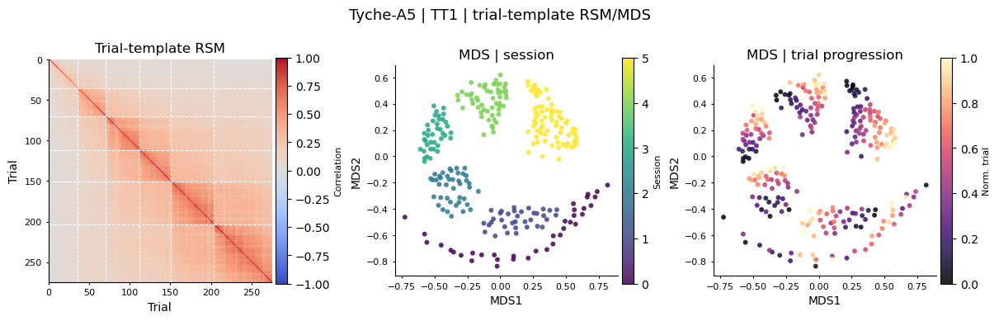

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_TT1_trial_template_RSM_MDS.pdf
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/Tyche-A5_TT1_trial_template_RSM_MDS.png


In [101]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# -----------------------------
# parameters
# -----------------------------

animal = animals[1]
data = Data_trial[animal]

trial_type = 1
use_engaged = True

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# build trial templates
# -----------------------------

X_trials = []
session_vals = []
trial_vals = []
session_boundaries = []

counter = 0
n_sessions = len(data["fields"])

for sess in range(n_sessions):

    PF = np.asarray(data["fields"][sess], float)  # trials x cells x bins
    tt = np.asarray(data["trial_types"][sess])

    idx = np.where(tt == trial_type)[0]
    PF = PF[idx]

    if use_engaged:
        engaged_trials = get_engaged_trials(PF, z_threshold=-2)
        PF = PF[engaged_trials]

    n_trials = PF.shape[0]

    if n_trials < 3:
        continue

    # each trial template = cells x spatial bins flattened
    X = PF.reshape(n_trials, -1)
    X = np.nan_to_num(X)

    X_trials.append(X)

    session_vals.extend([sess] * n_trials)
    trial_vals.extend(np.arange(n_trials))

    counter += n_trials
    session_boundaries.append(counter)

X_trials = np.vstack(X_trials)
session_vals = np.asarray(session_vals)
trial_vals = np.asarray(trial_vals)

# -----------------------------
# RSM and MDS
# -----------------------------

R = np.corrcoef(X_trials)
R = np.nan_to_num(R, nan=0, posinf=0, neginf=0)

D = 1 - R
D[D < 0] = 0

mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=0,
    normalized_stress="auto"
)

emb = mds.fit_transform(D)

# normalize trial number within each session
trial_vals_norm = np.zeros_like(trial_vals, dtype=float)

for sess in np.unique(session_vals):

    m = session_vals == sess
    vals = trial_vals[m].astype(float)

    if len(np.unique(vals)) > 1:
        trial_vals_norm[m] = (vals - vals.min()) / (vals.max() - vals.min())
    else:
        trial_vals_norm[m] = 0

# -----------------------------
# plot
# -----------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3.8),
    constrained_layout=True
)

# Panel 1: RSM
ax = axes[0]

im = ax.imshow(
    R,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    origin="upper",
    aspect="equal"
)

for b in session_boundaries[:-1]:
    ax.axhline(b - 0.5, color="white", ls="--", lw=0.8)
    ax.axvline(b - 0.5, color="white", ls="--", lw=0.8)

ax.set_title("Trial-template RSM")
ax.set_xlabel("Trial")
ax.set_ylabel("Trial")

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Correlation", fontsize=8)

# Panel 2: MDS colored by session
ax = axes[1]

sc = ax.scatter(
    emb[:, 0],
    emb[:, 1],
    c=session_vals,
    cmap="viridis",
    s=18,
    alpha=0.85,
    linewidths=0
)

ax.set_title("MDS | session")
ax.set_xlabel("MDS1")
ax.set_ylabel("MDS2")
ax.set_aspect("equal", adjustable="box")

cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Session", fontsize=8)

# Panel 3: MDS colored by normalized trial
ax = axes[2]

sc = ax.scatter(
    emb[:, 0],
    emb[:, 1],
    c=trial_vals_norm,
    cmap="magma",
    vmin=0,
    vmax=1,
    s=18,
    alpha=0.85,
    linewidths=0
)

ax.set_title("MDS | trial progression")
ax.set_xlabel("MDS1")
ax.set_ylabel("MDS2")
ax.set_aspect("equal", adjustable="box")

cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Norm. trial", fontsize=8)

for ax in axes:
    ax.tick_params(labelsize=8, length=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    f"{animal} | TT{trial_type} | trial-template RSM/MDS",
    fontsize=13
)

pdf_path = os.path.join(
    save_dir,
    f"{animal}_TT{trial_type}_trial_template_RSM_MDS.pdf"
)

png_path = os.path.join(
    save_dir,
    f"{animal}_TT{trial_type}_trial_template_RSM_MDS.png"
)

fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")

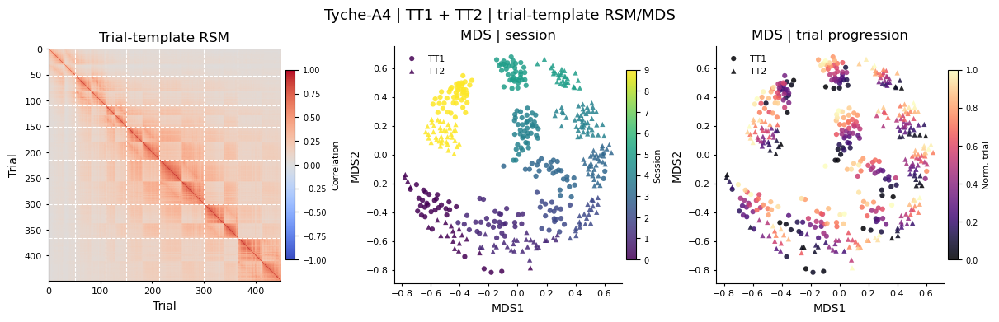

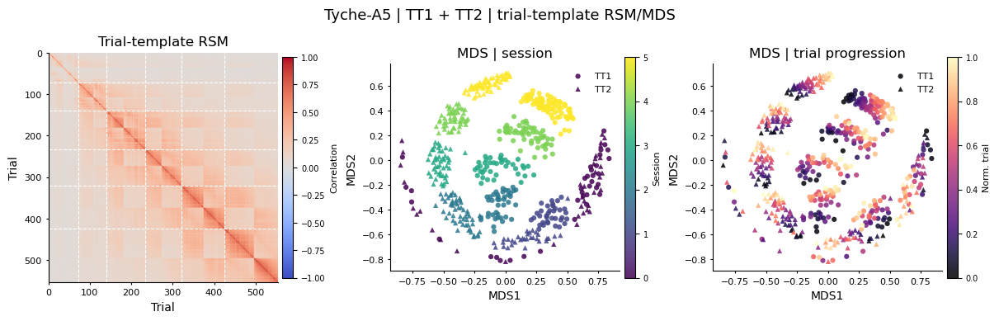

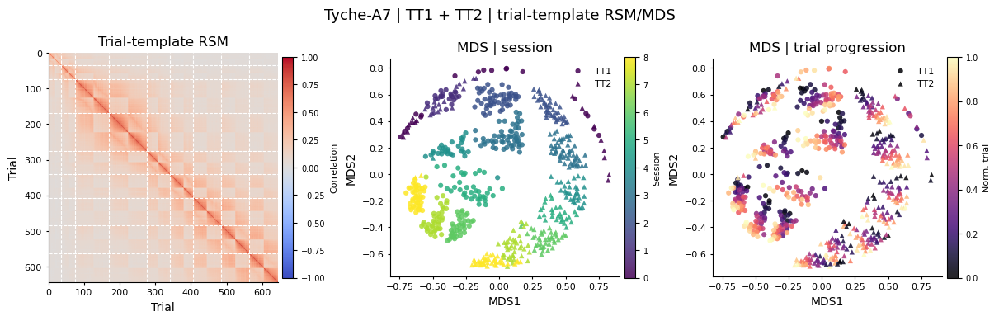

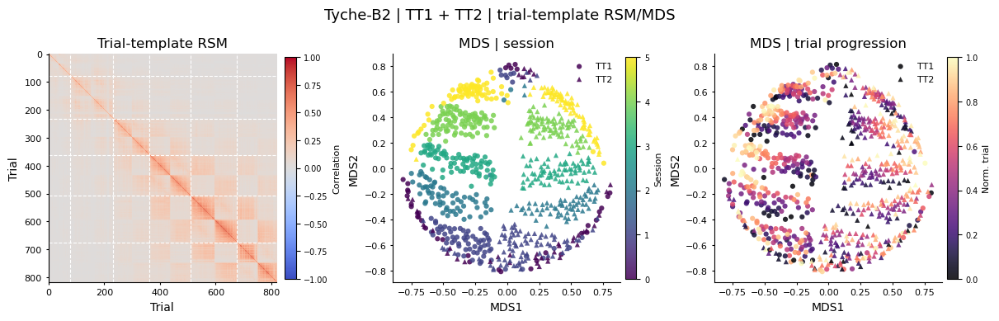

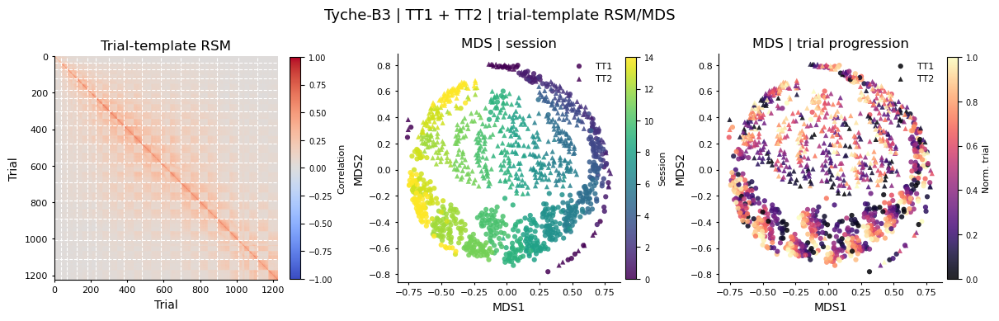

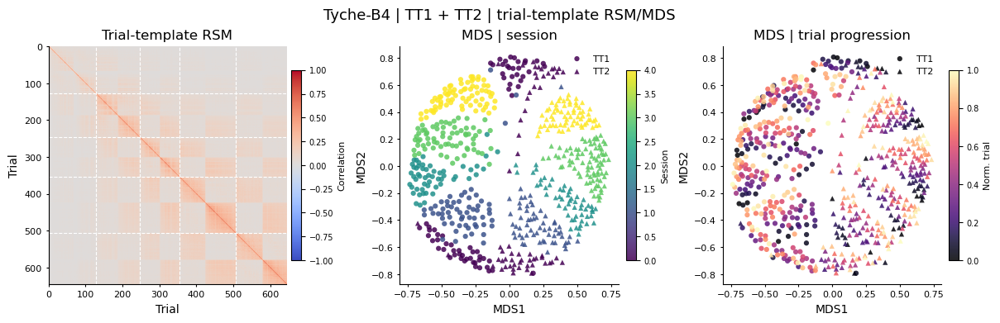

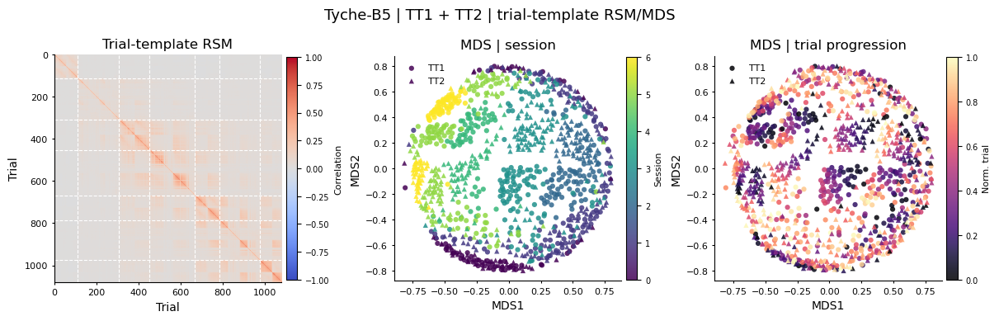

Saved combined PDF:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/ALL_animals_TT1_TT2_trial_template_RSM_MDS.pdf


In [102]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# parameters
# -----------------------------

trial_types_to_include = [1, 2]
use_engaged = True

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

markers = {
    1: "o",
    2: "^"
}

exclude = {
    0: [6, 7, 8],
    3: [6]
}

# -----------------------------
# helper
# -----------------------------

def build_trial_template_mds_for_animal(
    animal,
    ai,
    trial_types_to_include=[1, 2],
    use_engaged=True
):

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    X_trials = []
    session_vals = []
    trial_vals = []
    trial_type_vals = []
    session_boundaries = []

    counter = 0

    for sess in range(n_sessions):

        if ai in exclude and sess in exclude[ai]:
            continue

        PF_all = np.asarray(data["fields"][sess], float)
        tt_all = np.asarray(data["trial_types"][sess])

        for trial_type in trial_types_to_include:

            idx = np.where(tt_all == trial_type)[0]
            PF = PF_all[idx]

            if use_engaged:
                engaged_trials = get_engaged_trials(PF, z_threshold=-2)
                PF = PF[engaged_trials]

            n_trials = PF.shape[0]

            if n_trials < 3:
                continue

            # each trial template = cells x spatial bins flattened
            X = PF.reshape(n_trials, -1)
            X = np.nan_to_num(X)

            X_trials.append(X)

            session_vals.extend([sess] * n_trials)
            trial_vals.extend(np.arange(n_trials))
            trial_type_vals.extend([trial_type] * n_trials)

            counter += n_trials

        # boundary after all valid TT trials in this session
        if counter > 0:
            session_boundaries.append(counter)

    if len(X_trials) == 0:
        return None

    X_trials = np.vstack(X_trials)
    session_vals = np.asarray(session_vals)
    trial_vals = np.asarray(trial_vals)
    trial_type_vals = np.asarray(trial_type_vals)

    # RSM
    R = np.corrcoef(X_trials)
    R = np.nan_to_num(R, nan=0, posinf=0, neginf=0)

    D = 1 - R
    D[D < 0] = 0

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=0,
        normalized_stress="auto"
    )

    emb = mds.fit_transform(D)

    # normalize trial within animal/session/trial type
    trial_vals_norm = np.zeros_like(trial_vals, dtype=float)

    for sess in np.unique(session_vals):
        for tt in np.unique(trial_type_vals):

            m = (session_vals == sess) & (trial_type_vals == tt)
            vals = trial_vals[m].astype(float)

            if len(vals) == 0:
                continue

            if len(np.unique(vals)) > 1:
                trial_vals_norm[m] = (
                    (vals - vals.min())
                    / (vals.max() - vals.min())
                )
            else:
                trial_vals_norm[m] = 0

    return {
        "animal": animal,
        "X": X_trials,
        "R": R,
        "D": D,
        "emb": emb,
        "session_vals": session_vals,
        "trial_vals": trial_vals,
        "trial_vals_norm": trial_vals_norm,
        "trial_type_vals": trial_type_vals,
        "session_boundaries": session_boundaries
    }


def plot_trial_template_mds_result(res, save_dir=None, save=True):

    animal = res["animal"]
    R = res["R"]
    emb = res["emb"]

    session_vals = res["session_vals"]
    trial_vals_norm = res["trial_vals_norm"]
    trial_type_vals = res["trial_type_vals"]
    session_boundaries = res["session_boundaries"]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 3.8),
        constrained_layout=True
    )

    # -----------------------------
    # Panel 1: RSM
    # -----------------------------

    ax = axes[0]

    im = ax.imshow(
        R,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        origin="upper",
        aspect="equal"
    )

    for b in session_boundaries[:-1]:
        ax.axhline(b - 0.5, color="white", ls="--", lw=0.8)
        ax.axvline(b - 0.5, color="white", ls="--", lw=0.8)

    ax.set_title("Trial-template RSM")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Trial")

    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Correlation", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # -----------------------------
    # Panel 2: MDS colored by session
    # -----------------------------

    ax = axes[1]

    for tt in trial_types_to_include:

        m = trial_type_vals == tt

        sc = ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=session_vals[m],
            cmap="viridis",
            marker=markers[tt],
            s=20,
            alpha=0.85,
            linewidths=0,
            label=f"TT{tt}"
        )

    ax.set_title("MDS | session")
    ax.set_xlabel("MDS1")
    ax.set_ylabel("MDS2")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=False, fontsize=8)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Session", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # -----------------------------
    # Panel 3: MDS colored by normalized trial
    # -----------------------------

    ax = axes[2]

    for tt in trial_types_to_include:

        m = trial_type_vals == tt

        sc = ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=trial_vals_norm[m],
            cmap="magma",
            vmin=0,
            vmax=1,
            marker=markers[tt],
            s=20,
            alpha=0.85,
            linewidths=0,
            label=f"TT{tt}"
        )

    ax.set_title("MDS | trial progression")
    ax.set_xlabel("MDS1")
    ax.set_ylabel("MDS2")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=False, fontsize=8)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Norm. trial", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # -----------------------------
    # styling
    # -----------------------------

    for ax in axes:
        ax.tick_params(labelsize=8, length=2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{animal} | TT1 + TT2 | trial-template RSM/MDS",
        fontsize=13
    )

    if save and save_dir is not None:

        pdf_path = os.path.join(
            save_dir,
            f"{animal}_TT1_TT2_trial_template_RSM_MDS.pdf"
        )

        png_path = os.path.join(
            save_dir,
            f"{animal}_TT1_TT2_trial_template_RSM_MDS.png"
        )

        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
        fig.savefig(png_path, dpi=300, bbox_inches="tight")

    return fig, axes


# -----------------------------
# run for all animals
# -----------------------------

all_trial_template_mds = {}

multi_pdf_path = os.path.join(
    save_dir,
    "ALL_animals_TT1_TT2_trial_template_RSM_MDS.pdf"
)

with PdfPages(multi_pdf_path) as pdf:

    for ai, animal in enumerate(animals):

        res = build_trial_template_mds_for_animal(
            animal=animal,
            ai=ai,
            trial_types_to_include=trial_types_to_include,
            use_engaged=use_engaged
        )

        if res is None:
            print(f"{animal}: skipped")
            continue

        all_trial_template_mds[animal] = res

        fig, axes = plot_trial_template_mds_result(
            res,
            save_dir=save_dir,
            save=True
        )

        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print(f"Saved combined PDF:\n{multi_pdf_path}")

In [104]:
def plot_trial_template_mds_result(res, save_dir=None, save=True):

    animal = res["animal"]
    R = res["R"]
    emb = res["emb"]

    session_vals = res["session_vals"]
    trial_vals_norm = res["trial_vals_norm"]
    trial_type_vals = res["trial_type_vals"]
    session_boundaries = res["session_boundaries"]

    # ---------------------------------------------------
    # figure: 2 rows = TT1 / TT2
    # ---------------------------------------------------

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(12, 7.2),
        constrained_layout=True,
        sharex=False,
        sharey=False
    )

    # ===================================================
    # LEFT COLUMN: RSM
    # same RSM repeated for both rows for visual symmetry
    # ===================================================

    for row, tt in enumerate([1, 2]):

        ax = axes[row, 0]

        im = ax.imshow(
            R,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            origin="upper",
            aspect="equal"
        )

        for b in session_boundaries[:-1]:
            ax.axhline(b - 0.5, color="white", ls="--", lw=0.8)
            ax.axvline(b - 0.5, color="white", ls="--", lw=0.8)

        if row == 0:
            ax.set_title("Trial-template RSM", fontsize=11)

        ax.set_xlabel("Trial")
        ax.set_ylabel(f"TT{tt}\nTrial")

        cbar = fig.colorbar(
            im,
            ax=ax,
            shrink=0.78,
            pad=0.02
        )

        cbar.set_label("Correlation", fontsize=8)
        cbar.ax.tick_params(labelsize=7)

    # ===================================================
    # MIDDLE + RIGHT columns
    # ===================================================

    for row, tt in enumerate([1, 2]):

        mask = trial_type_vals == tt

        marker = markers[tt]

        # ------------------------------------------------
        # MDS | session
        # ------------------------------------------------

        ax = axes[row, 1]

        sc = ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            c=session_vals[mask],
            cmap="viridis",
            marker=marker,
            s=20,
            alpha=0.85,
            linewidths=0
        )

        if row == 0:
            ax.set_title("MDS | session", fontsize=11)

        ax.set_xlabel("MDS1")
        ax.set_ylabel(f"TT{tt}\nMDS2")

        ax.set_aspect("equal", adjustable="box")

        cbar = fig.colorbar(
            sc,
            ax=ax,
            shrink=0.78,
            pad=0.02
        )

        cbar.set_label("Session", fontsize=8)
        cbar.ax.tick_params(labelsize=7)

        # ------------------------------------------------
        # MDS | normalized trial progression
        # ------------------------------------------------

        ax = axes[row, 2]

        sc = ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            c=trial_vals_norm[mask],
            cmap="magma",
            vmin=0,
            vmax=1,
            marker=marker,
            s=20,
            alpha=0.85,
            linewidths=0
        )

        if row == 0:
            ax.set_title("MDS | trial progression", fontsize=11)

        ax.set_xlabel("MDS1")
        ax.set_ylabel(f"TT{tt}\nMDS2")

        ax.set_aspect("equal", adjustable="box")

        cbar = fig.colorbar(
            sc,
            ax=ax,
            shrink=0.78,
            pad=0.02
        )

        cbar.set_label("Norm. trial", fontsize=8)
        cbar.ax.tick_params(labelsize=7)

    # ---------------------------------------------------
    # styling
    # ---------------------------------------------------

    for ax_row in axes:
        for ax in ax_row:

            ax.tick_params(
                labelsize=8,
                length=2
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{animal} | TT1 + TT2 | trial-template RSM/MDS",
        fontsize=13
    )

    # ---------------------------------------------------
    # save
    # ---------------------------------------------------

    if save and save_dir is not None:

        pdf_path = os.path.join(
            save_dir,
            f"{animal}_TT1_TT2_trial_template_RSM_MDS_2x3.pdf"
        )

        png_path = os.path.join(
            save_dir,
            f"{animal}_TT1_TT2_trial_template_RSM_MDS_2x3.png"
        )

        fig.savefig(
            pdf_path,
            dpi=300,
            bbox_inches="tight"
        )

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight"
        )

    return fig, axes

In [6]:
all_trial_template_mds = {}
markers = {
    1: "o",
    2: "o"
}
multi_pdf_path = os.path.join(
    save_dir,
    "ALL_animals_TT1_TT2_trial_template_RSM_MDS_2x3.pdf"
)

with PdfPages(multi_pdf_path) as pdf:

    for ai, animal in enumerate(animals):

        res = build_trial_template_mds_for_animal(
            animal=animal,
            ai=ai,
            trial_types_to_include=[1, 2],
            use_engaged=True
        )

        if res is None:
            print(f"{animal}: skipped")
            continue

        all_trial_template_mds[animal] = res

        fig, axes = plot_trial_template_mds_result(
            res,
            save_dir=save_dir,
            save=True
        )

        pdf.savefig(fig, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print(f"Saved combined PDF:\n{multi_pdf_path}")

NameError: name 'PdfPages' is not defined

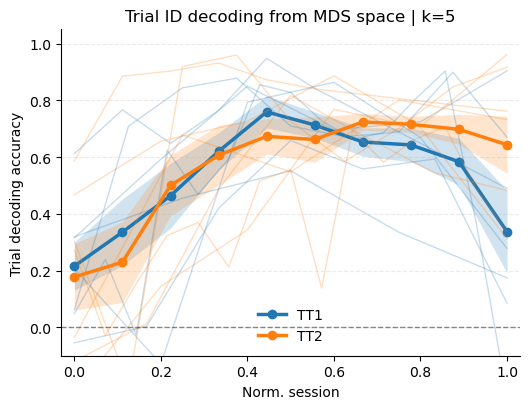

Saved:
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/KNN_trial_ID_regression_from_MDS_TT1_TT2_k5.pdf
/home/mohammad/nas4/mohammad.yaghoubi/WR-2p/Results - paper/KNN_trial_ID_regression_from_MDS_TT1_TT2_k5.png


In [121]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score
from sklearn.neighbors import NearestNeighbors

save_dir = "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results - paper"
os.makedirs(save_dir, exist_ok=True)

k_neighbors = 5
n_interp = 10
x_common = np.linspace(0, 1, n_interp)

colors = {
    1: "tab:blue",
    2: "tab:orange"
}

def knn_trial_regression_r2(emb, trial_vals, k=5):
    emb = np.asarray(emb, float)
    trial_vals = np.asarray(trial_vals, float)

    valid = np.isfinite(emb).all(axis=1) & np.isfinite(trial_vals)
    emb = emb[valid]
    trial_vals = trial_vals[valid]

    if len(emb) < k + 2 or len(np.unique(trial_vals)) < 3:
        return np.nan

    # normalize trial ID
    y = (trial_vals - trial_vals.min()) / (trial_vals.max() - trial_vals.min())

    nn = NearestNeighbors(n_neighbors=min(k + 1, len(emb)))
    nn.fit(emb)

    _, idx = nn.kneighbors(emb)

    # remove self-neighbor
    idx = idx[:, 1:]

    y_pred = np.array([np.mean(y[ii]) for ii in idx])

    return r2_score(y, y_pred)

# compute per animal / session / TT
rows = []
for animal, res in all_trial_template_mds.items():

    emb = res["emb"]
    session_vals = res["session_vals"]
    trial_vals = res["trial_vals"]
    trial_type_vals = res["trial_type_vals"]

    for sess in np.unique(session_vals):

        for tt in [1, 2]:

            mask = ((session_vals == sess) & (trial_type_vals == tt))

            if np.sum(mask) < k_neighbors + 2:
                score = np.nan
            else:
                score = knn_trial_regression_r2(emb[mask], trial_vals[mask], k=k_neighbors)

            rows.append({"animal": animal, "session": sess, "trial_type": tt, "knn_trial_acc": score})

df_knn_trial = pd.DataFrame(rows)

# normalize session within animal
df_knn_trial["session_norm"] = np.nan

for animal in df_knn_trial["animal"].unique():

    m = df_knn_trial["animal"] == animal
    sess_vals = df_knn_trial.loc[m, "session"].values.astype(float)

    if len(np.unique(sess_vals)) > 1:
        df_knn_trial.loc[m, "session_norm"] = ((sess_vals - np.nanmin(sess_vals)) / (np.nanmax(sess_vals) - np.nanmin(sess_vals)))
    else:
        df_knn_trial.loc[m, "session_norm"] = 0


# interpolate animal curves
curves = {1: [], 2: []}

for tt in [1, 2]:

    for animal in df_knn_trial["animal"].unique():
        d = (df_knn_trial[(df_knn_trial["animal"] == animal) & (df_knn_trial["trial_type"] == tt)].dropna(subset=["knn_trial_acc", "session_norm"]).sort_values("session_norm"))
        if len(d) < 2:
            continue
        curve = np.interp(x_common, d["session_norm"].values, d["knn_trial_acc"].values)
        curves[tt].append(curve)

for tt in [1, 2]:
    curves[tt] = np.asarray(curves[tt])


# plot
fig, ax = plt.subplots(figsize=(5.4, 4.2))
for tt in [1, 2]:

    # individual animal lines
    for animal in df_knn_trial["animal"].unique():
        d = (df_knn_trial[(df_knn_trial["animal"] == animal) & (df_knn_trial["trial_type"] == tt)].dropna(subset=["knn_trial_acc", "session_norm"]).sort_values("session_norm"))
        if len(d) < 2:
            continue
        ax.plot(d["session_norm"], d["knn_trial_acc"], "-", color=colors[tt], alpha=0.25, lw=1, ms=3)

    # mean ± SEM
    mean_curve = np.nanmean(curves[tt], axis=0)
    sem_curve = np.nanstd(curves[tt], axis=0, ddof=1) / np.sqrt(curves[tt].shape[0])
    ax.plot(x_common, mean_curve, "-o", color=colors[tt], lw=2.5, ms=6, label=f"TT{tt}")
    ax.fill_between(x_common, mean_curve - sem_curve, mean_curve + sem_curve, color=colors[tt], alpha=0.2, linewidth=0)

ax.axhline(0, color="k", ls="--", lw=1, alpha=0.45)

ax.set_xlabel("Norm. session")
ax.set_ylabel("Trial decoding accuracy")
ax.set_title(f"Trial ID decoding from MDS space | k={k_neighbors}")

ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.1, 1.05)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")

plt.tight_layout()

pdf_path = os.path.join(save_dir, f"KNN_trial_ID_regression_from_MDS_TT1_TT2_k{k_neighbors}.pdf")
png_path = os.path.join(save_dir, f"KNN_trial_ID_regression_from_MDS_TT1_TT2_k{k_neighbors}.png")

fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved:\n{pdf_path}\n{png_path}")9*+``

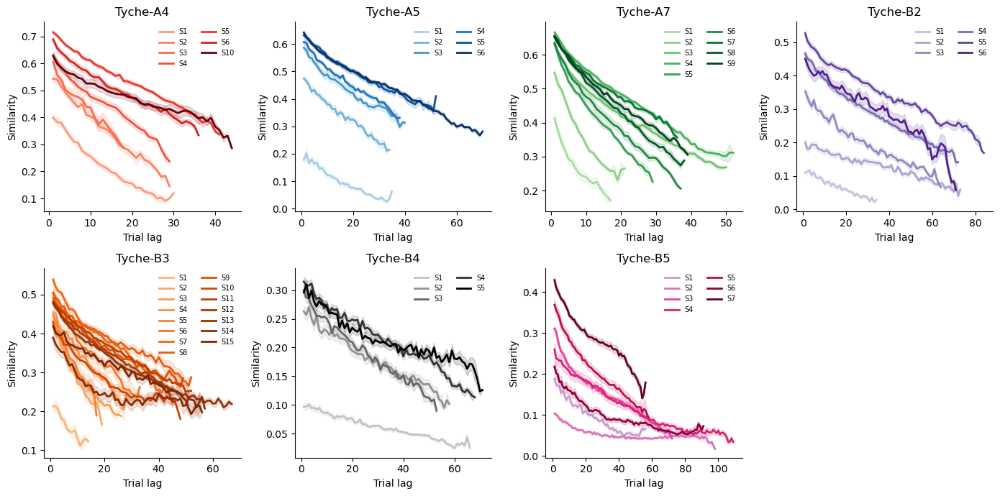

In [38]:
trial_type = 1
# one base colormap per animal
animal_cmaps = [
    cm.Reds,
    cm.Blues,
    cm.Greens,
    cm.Purples,
    cm.Oranges,
    cm.Greys,
    cm.PuRd]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

axes = axes.ravel()

for ai, animal in enumerate(animals):

    ax = axes[ai]

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    # gradient within animal
    cmap = animal_cmaps[ai]
    colors = cmap(np.linspace(0.35, 1, n_sessions))

    for sess in range(n_sessions):

        # exclusions
        if ai == 0 and sess in [6, 7, 8]:
            continue

        if ai == 3 and sess == 6:
            continue
        
        PF = np.asarray(data["fields"][sess], float)
        tt = np.asarray(data["trial_types"][sess])
        idx = np.where(tt == trial_type)[0]
        PF = PF[idx]

        engaged_trials = get_engaged_trials(PF, z_threshold=-2)
        PF = PF[engaged_trials]
        
        n_trials = PF.shape[0]
        if n_trials < 5:
            continue
        X = PF.reshape(n_trials, -1)
        X = np.nan_to_num(X)
        RSM = np.corrcoef(X)
        max_lag = n_trials - 1

        lag_vals, lag_sem = [], []
        for lag in range(1, max_lag + 1):
            vals = []
            for i in range(n_trials - lag):
                vals.append(RSM[i, i + lag])

            vals = np.asarray(vals)
            lag_vals.append(np.nanmean(vals))
            lag_sem.append(np.nanstd(vals) / np.sqrt(np.sum(np.isfinite(vals))))

        lag_vals = np.asarray(lag_vals)
        lag_sem = np.asarray(lag_sem)
        x = np.arange(1, max_lag + 1)

        ax.plot(x, lag_vals, color=colors[sess], lw=2, label=f"S{sess+1}")
        ax.fill_between(x, lag_vals - lag_sem, lag_vals + lag_sem, color=colors[sess], alpha=0.15)

    ax.set_title(animal)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Trial lag")
    ax.set_ylabel("Similarity")

    ax.legend(frameon=False, fontsize=7, ncol=2)

# remove empty 8th panel
for ax in axes[len(animals):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

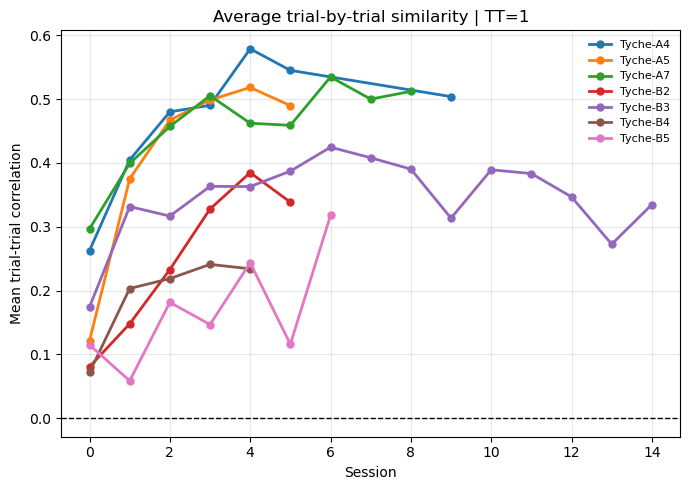

In [39]:
trial_type = 1
fig, ax = plt.subplots(figsize=(7, 5))

for animal in animals:

    data = Data_trial[animal]
    n_sessions = len(data["fields"])

    mean_corrs = []
    valid_sessions = []

    for sess in range(n_sessions):

        # exclusions
        if animal == animals[0] and sess in [6, 7, 8]:
            continue

        if animal == animals[3] and sess == 6:
            continue

        PF = np.asarray(data["fields"][sess], float)
        tt = np.asarray(data["trial_types"][sess])

        idx = np.where(tt == trial_type)[0]
        PF = PF[idx]

        engaged_trials = get_engaged_trials(PF, z_threshold=-2)
        PF = PF[engaged_trials]

        n_trials = PF.shape[0]

        if n_trials < 5:
            continue

        X = PF.reshape(n_trials, -1)
        X = np.nan_to_num(X)

        RSM = np.corrcoef(X)

        # remove diagonal
        mask = ~np.eye(RSM.shape[0], dtype=bool)

        mean_rsm = np.nanmean(RSM[mask])
        mean_corrs.append(mean_rsm)
        valid_sessions.append(sess)

    ax.plot(valid_sessions, mean_corrs, '-o', lw=2, ms=5, label=animal)

ax.axhline(0, color='k', linestyle='--', linewidth=1)

ax.set_xlabel("Session")
ax.set_ylabel("Mean trial-trial correlation")
ax.set_title(f"Average trial-by-trial similarity | TT={trial_type}")

ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

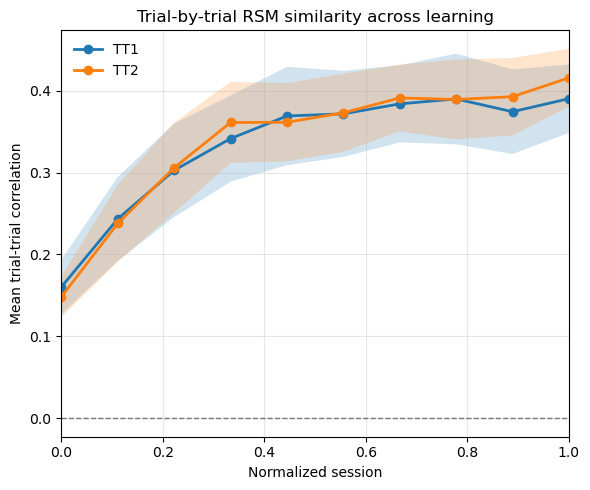

In [40]:
n_points = 10
x_common = np.linspace(0, 1, n_points)
all_curves = {1: [], 2: []}

for trial_type in [1, 2]:

    for ai, animal in enumerate(animals):

        data = Data_trial[animal]
        n_sessions = len(data["fields"])

        mean_corrs = []
        sess_ids = []

        for sess in range(n_sessions):

            # exclusions
            if ai == 0 and sess in [6, 7, 8]:
                continue

            if ai == 3 and sess == 6:
                continue

            PF = np.asarray(data["fields"][sess], float)
            tt = np.asarray(data["trial_types"][sess])

            idx = np.where(tt == trial_type)[0]
            PF = PF[idx]

            engaged_trials = get_engaged_trials(PF, z_threshold=-2)
            PF = PF[engaged_trials]
            
            n_trials = PF.shape[0]

            if n_trials < 5:
                continue

            X = PF.reshape(n_trials, -1)
            X = np.nan_to_num(X)

            RSM = np.corrcoef(X)

            # mean off-diagonal similarity
            mask = ~np.eye(RSM.shape[0], dtype=bool)
            mean_rsm = np.nanmean(RSM[mask])

            mean_corrs.append(mean_rsm)
            sess_ids.append(sess)

        mean_corrs = np.asarray(mean_corrs, float)
        sess_ids = np.asarray(sess_ids, float)

        if len(mean_corrs) < 2:
            continue

        # normalize sessions to [0, 1]
        x_scaled = (sess_ids - sess_ids.min()) / (sess_ids.max() - sess_ids.min())

        # interpolate to common axis
        curve_interp = np.interp(x_common, x_scaled, mean_corrs)
        all_curves[trial_type].append(curve_interp)

# convert to arrays
curves_tt1 = np.asarray(all_curves[1])
curves_tt2 = np.asarray(all_curves[2])
curves_all = np.concatenate([curves_tt1, curves_tt2], axis=0)

# mean / sem
mean_tt1 = np.nanmean(curves_tt1, axis=0)
sem_tt1 = np.nanstd(curves_tt1, axis=0, ddof=1) / np.sqrt(curves_tt1.shape[0])

mean_tt2 = np.nanmean(curves_tt2, axis=0)
sem_tt2 = np.nanstd(curves_tt2, axis=0, ddof=1) / np.sqrt(curves_tt2.shape[0])

mean_all = np.nanmean(curves_all, axis=0)
sem_all = np.nanstd(curves_all, axis=0, ddof=1) / np.sqrt(curves_all.shape[0])

# plot
fig, ax = plt.subplots(figsize=(6, 5))

# TT1
ax.plot(x_common, mean_tt1, '-o', lw=2, ms=6, label='TT1')
ax.fill_between(x_common, mean_tt1 - sem_tt1, mean_tt1 + sem_tt1, alpha=0.2)

# TT2
ax.plot(x_common, mean_tt2, '-o', lw=2, ms=6, label='TT2')
ax.fill_between(x_common, mean_tt2 - sem_tt2, mean_tt2 + sem_tt2, alpha=0.2)

# all
# ax.plot(x_common, mean_all, '-o', lw=2, ms=6, color='k', label='All')
# ax.fill_between(x_common, mean_all - sem_all, mean_all + sem_all, alpha=0.2, color='k')

ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel("Normalized session")
ax.set_ylabel("Mean trial-trial correlation")
ax.set_title("Trial-by-trial RSM similarity across learning")

ax.set_xlim(0, 1)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

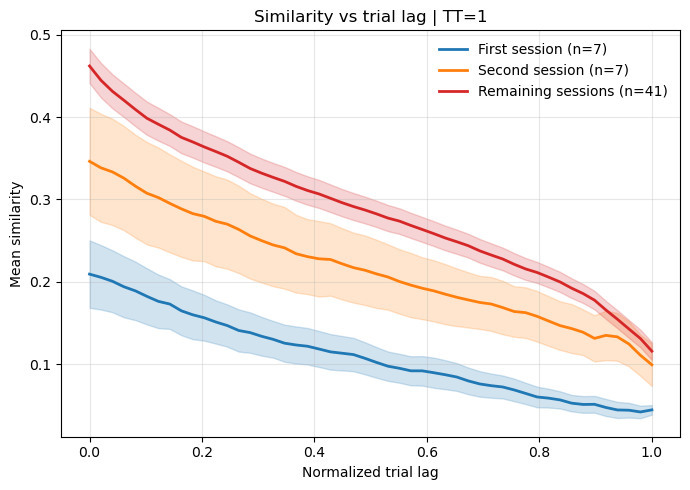

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# parameters

trial_type = 1
n_interp = 50

exclude = {0: [6, 7, 8], 3: [6]}

# -------------------------------------------------------
# helper
def sim_vs_lag(RSM):

    n = RSM.shape[0]

    lags = []
    sims = []

    for lag in range(1, n):

        vals = np.diag(RSM, k=lag)

        if len(vals) == 0:
            continue

        lags.append(lag)
        sims.append(np.nanmean(vals))

    return np.asarray(lags), np.asarray(sims)

# -------------------------------------------------------
# groups
# -------------------------------------------------------

groups = {
    "session_1": [],
    "session_2": [],
    "session_3plus": []
}

x_common = np.linspace(0, 1, n_interp)

# -------------------------------------------------------
# loop animals
# -------------------------------------------------------

for ai, animal in enumerate(animals):

    data = Data_trial[animal]
    n_sessions_total = len(data["fields"])

    # valid sessions
    valid_sessions = []

    for sess in range(n_sessions_total):

        if ai in exclude and sess in exclude[ai]:
            continue

        valid_sessions.append(sess)

    valid_sessions = np.asarray(valid_sessions)

    if len(valid_sessions) < 2:
        continue

    # ---------------------------------------------------
    # loop sessions
    # ---------------------------------------------------

    for order_idx, sess in enumerate(valid_sessions):

        PF = np.asarray(data["fields"][sess], float)
        tt = np.asarray(data["trial_types"][sess])

        idx = np.where(tt == trial_type)[0]
        PF = PF[idx]

        n_trials = PF.shape[0]

        if n_trials < 5:
            continue

        X = PF.reshape(n_trials, -1)
        X = np.nan_to_num(X)

        RSM = np.corrcoef(X)

        lags, sims = sim_vs_lag(RSM)

        if len(sims) < 3:
            continue

        # normalize lag axis
        x_scaled = (
            (lags - lags.min())
            / (lags.max() - lags.min())
        )

        sims_interp = np.interp(x_common, x_scaled, sims)

        # assign group
        if order_idx == 0:
            groups["session_1"].append(sims_interp)

        elif order_idx == 1:
            groups["session_2"].append(sims_interp)

        else:
            groups["session_3plus"].append(sims_interp)

# -------------------------------------------------------
# convert arrays
# -------------------------------------------------------

for k in groups:
    groups[k] = np.asarray(groups[k])

# -------------------------------------------------------
# plot
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

colors = {
    "session_1": "tab:blue",
    "session_2": "tab:orange",
    "session_3plus": "tab:red"
}

labels = {
    "session_1": "First session",
    "session_2": "Second session",
    "session_3plus": "Remaining sessions"
}

for k in ["session_1", "session_2", "session_3plus"]:

    curves = groups[k]

    mean_curve = np.nanmean(curves, axis=0)

    sem_curve = (
        np.nanstd(curves, axis=0, ddof=1)
        / np.sqrt(curves.shape[0])
    )

    ax.plot(
        x_common,
        mean_curve,
        lw=2,
        color=colors[k],
        label=f"{labels[k]} (n={curves.shape[0]})"
    )

    ax.fill_between(
        x_common,
        mean_curve - sem_curve,
        mean_curve + sem_curve,
        color=colors[k],
        alpha=0.2
    )

ax.set_xlabel("Normalized trial lag")
ax.set_ylabel("Mean similarity")
ax.set_title(f"Similarity vs trial lag | TT={trial_type}")

ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()